In [ ]:
!pip install -q scanpy anndata pyarrow tifffile opencv-python scikit-learn timm h5py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 92.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 88.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 32.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 103.5 MB/s eta 0:00:0000:0100:01


In [1]:
# ============================================================
# Dataset paths + preprocessing verification for the paper
# Actual configuration used in the single-cell Xenium notebook
# ============================================================

import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import tifffile

from scipy.sparse import issparse
from sklearn.neighbors import NearestNeighbors


# ============================================================
# 1. Dataset paths
# ============================================================

REP1 = {
    "name": "Rep1",
    "split": "Training",
    "he": (
        "/kaggle/input/datasets/sajidml/xenium-rep1/Rep1/"
        "GSM7780153_Post-Xenium_HE_Rep1.ome.tif/"
        "GSM7780153_Post-Xenium_HE_Rep1.ome.tif"
    ),
    "h5": (
        "/kaggle/input/datasets/sajidml/xenium-rep1/Rep1/"
        "GSE243168_RAW/cell_feature_matrix.h5"
    ),
    "cells": (
        "/kaggle/input/datasets/sajidml/xenium-rep1/Rep1/"
        "GSE243168_RAW/cells.parquet"
    ),
    "boundaries": (
        "/kaggle/input/datasets/sajidml/xenium-rep1/Rep1/"
        "GSE243168_RAW/cell_boundaries.parquet"
    ),
}

REP2 = {
    "name": "Rep2",
    "split": "Independent test",
    "he": (
        "/kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/"
        "GSM7780154_Post-Xenium_HE_Rep2.ome.tif/"
        "GSM7780154_Post-Xenium_HE_Rep2.ome.tif"
    ),
    "h5": (
        "/kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/"
        "GSM7780154_Xenium_FFPE_Human_Breast_Cancer_Rep2_outs/"
        "cell_feature_matrix.h5"
    ),
    "cells": (
        "/kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/"
        "GSM7780154_Xenium_FFPE_Human_Breast_Cancer_Rep2_outs/"
        "cells.parquet"
    ),
    "boundaries": (
        "/kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/"
        "GSM7780154_Xenium_FFPE_Human_Breast_Cancer_Rep2_outs/"
        "nucleus_boundaries.parquet"
    ),
}


# ============================================================
# 2. Actual preprocessing settings used in the notebook
# ============================================================

N_HVG = 300
K_NEIGHBORS = 8

PATCH_SIZE = 512
MODEL_IMAGE_SIZE = 224

WHITE_THRESHOLD = 0.75
BLACK_THRESHOLD = 0.15
MIN_GRAYSCALE_STD = 0.05

LIBRARY_SIZE = 1e4

IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406], dtype=np.float32
)
IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225], dtype=np.float32
)

OUTPUT_DIR = Path(
    "/kaggle/working/MDNAL_Preprocessing_Outputs"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3. Validate dataset files
# ============================================================

def validate_paths(dataset):
    print(f"\n{dataset['name']} — {dataset['split']}")

    for key in ["he", "h5", "cells", "boundaries"]:
        path = dataset[key]
        exists = os.path.exists(path)
        is_file = os.path.isfile(path)

        print(
            f"{key:12s} | exists={str(exists):5s} | "
            f"file={str(is_file):5s} | {path}"
        )

        if not exists or not is_file:
            raise FileNotFoundError(
                f"Required {key} file was not found: {path}"
            )


for dataset in [REP1, REP2]:
    validate_paths(dataset)


# ============================================================
# 4. Load cells and expression matrices
# ============================================================

def load_cells(path):
    df = pd.read_parquet(path)

    if "cell_id" in df.columns:
        id_col = "cell_id"
    else:
        id_col = df.columns[0]

    possible_coordinates = [
        ("x_centroid", "y_centroid"),
        ("x_center", "y_center"),
        ("center_x", "center_y"),
        ("x", "y"),
    ]

    x_col, y_col = None, None

    for candidate_x, candidate_y in possible_coordinates:
        if (
            candidate_x in df.columns
            and candidate_y in df.columns
        ):
            x_col = candidate_x
            y_col = candidate_y
            break

    if x_col is None or y_col is None:
        raise ValueError(
            f"No supported coordinate columns were found in {path}"
        )

    df = df[[id_col, x_col, y_col]].copy()
    df.columns = ["cell_id", "x", "y"]
    df["cell_id"] = df["cell_id"].astype(str)

    return df


def load_expression(path):
    adata = sc.read_10x_h5(path)
    adata.var_names_make_unique()
    adata.obs_names = adata.obs_names.astype(str)
    return adata


def align_cells(adata, cells):
    common_ids = np.intersect1d(
        adata.obs_names.values,
        cells["cell_id"].values,
    )

    if len(common_ids) == 0:
        raise ValueError(
            "No matching cell IDs were found between the "
            "expression matrix and cells.parquet."
        )

    aligned_adata = adata[common_ids].copy()
    aligned_cells = (
        cells.set_index("cell_id")
        .loc[common_ids]
        .copy()
    )

    aligned_adata.obs["x"] = aligned_cells["x"].values
    aligned_adata.obs["y"] = aligned_cells["y"].values

    return aligned_adata


cells1 = load_cells(REP1["cells"])
cells2 = load_cells(REP2["cells"])

adata1 = align_cells(
    load_expression(REP1["h5"]),
    cells1,
)
adata2 = align_cells(
    load_expression(REP2["h5"]),
    cells2,
)

print("\nAligned expression matrices")
print("Rep1:", adata1.shape)
print("Rep2:", adata2.shape)


# ============================================================
# 5. Select HVGs from Rep1 only
# ============================================================

def select_hvgs(adata, n_hvg):
    ad = adata.copy()

    sc.pp.filter_cells(ad, min_counts=20)
    sc.pp.filter_genes(ad, min_cells=10)

    sc.pp.normalize_total(
        ad,
        target_sum=LIBRARY_SIZE,
    )
    sc.pp.log1p(ad)

    sc.pp.highly_variable_genes(
        ad,
        n_top_genes=n_hvg,
        flavor="seurat",
    )

    genes = (
        ad.var.index[
            ad.var["highly_variable"]
        ]
        .astype(str)
        .tolist()
    )

    if len(genes) < n_hvg:
        print(
            f"Warning: requested {n_hvg} HVGs, "
            f"but only {len(genes)} were selected."
        )

    return genes


hvgs = select_hvgs(
    adata=adata1,
    n_hvg=N_HVG,
)

# Retain only genes available in both sections
shared_hvgs = [
    gene
    for gene in hvgs
    if gene in adata2.var_names
]

print("\nSelected Rep1 HVGs:", len(hvgs))
print("Shared Rep1–Rep2 HVGs:", len(shared_hvgs))


# ============================================================
# 6. Build normalized expression matrices
# ============================================================

def build_expression_matrix(adata, genes):
    ad = adata[:, genes].copy()

    sc.pp.normalize_total(
        ad,
        target_sum=LIBRARY_SIZE,
    )
    sc.pp.log1p(ad)

    coordinates = (
        ad.obs[["x", "y"]]
        .to_numpy(dtype=np.float32)
    )

    expression = ad.X

    if issparse(expression):
        expression = expression.toarray()

    expression = expression.astype(np.float32)
    cell_ids = ad.obs_names.to_numpy()

    return coordinates, expression, cell_ids


train_xy, train_y, train_ids = build_expression_matrix(
    adata1,
    shared_hvgs,
)

test_xy, test_y, test_ids = build_expression_matrix(
    adata2,
    shared_hvgs,
)


# ============================================================
# 7. Construct eight-neighbor expression targets
# ============================================================

def build_neighbor_expression(
    coordinates,
    expression,
    k=8,
):
    if len(coordinates) <= k:
        raise ValueError(
            f"At least {k + 1} cells are required."
        )

    knn = NearestNeighbors(
        n_neighbors=k + 1
    ).fit(coordinates)

    _, indices = knn.kneighbors(coordinates)

    # Remove the cell itself
    neighbor_indices = indices[:, 1:]

    neighbor_expression = expression[
        neighbor_indices
    ].mean(axis=1)

    return neighbor_expression.astype(np.float32)


train_neigh = build_neighbor_expression(
    train_xy,
    train_y,
    k=K_NEIGHBORS,
)

test_neigh = build_neighbor_expression(
    test_xy,
    test_y,
    k=K_NEIGHBORS,
)


# ============================================================
# 8. Standardize targets using Rep1 statistics only
# ============================================================

gene_mean = train_y.mean(
    axis=0,
    keepdims=True,
)

gene_std = (
    train_y.std(
        axis=0,
        keepdims=True,
    )
    + 1e-6
)

train_y_scaled = (
    train_y - gene_mean
) / gene_std

test_y_scaled = (
    test_y - gene_mean
) / gene_std

train_neigh_scaled = (
    train_neigh - gene_mean
) / gene_std

test_neigh_scaled = (
    test_neigh - gene_mean
) / gene_std


# ============================================================
# 9. Load H&E OME-TIFF images
# ============================================================

class HEImage:
    def __init__(self, path):
        self.path = path
        self.image = None

    def load(self):
        if self.image is None:
            image = tifffile.imread(self.path)

            if image.ndim == 2:
                image = np.stack(
                    [image, image, image],
                    axis=-1,
                )

            if (
                image.ndim == 3
                and image.shape[0] in [3, 4]
            ):
                image = np.transpose(
                    image[:3],
                    (1, 2, 0),
                )

            if (
                image.ndim == 3
                and image.shape[-1] > 3
            ):
                image = image[..., :3]

            if image.dtype != np.uint8:
                image = image.astype(np.float32)

                image = 255.0 * (
                    image - image.min()
                ) / (
                    image.max()
                    - image.min()
                    + 1e-8
                )

                image = image.astype(np.uint8)

            self.image = image

        return self.image

    def crop(self, x, y, size=512):
        image = self.load()

        height, width = image.shape[:2]

        x = int(round(x))
        y = int(round(y))
        radius = size // 2

        x1 = max(0, x - radius)
        x2 = min(width, x + radius)
        y1 = max(0, y - radius)
        y2 = min(height, y + radius)

        patch = image[y1:y2, x1:x2]

        pad_height = size - patch.shape[0]
        pad_width = size - patch.shape[1]

        if pad_height > 0 or pad_width > 0:
            patch = np.pad(
                patch,
                (
                    (0, max(0, pad_height)),
                    (0, max(0, pad_width)),
                    (0, 0),
                ),
                mode="constant",
                constant_values=255,
            )

        return patch[:size, :size]


rep1_he = HEImage(REP1["he"])
rep2_he = HEImage(REP2["he"])

rep1_image = rep1_he.load()
rep2_image = rep2_he.load()


# ============================================================
# 10. Scale Xenium coordinates to image pixel coordinates
# ============================================================

def scale_coordinates_to_image(
    coordinates,
    image,
):
    height, width = image.shape[:2]

    x_max = max(
        float(coordinates[:, 0].max()),
        1e-8,
    )
    y_max = max(
        float(coordinates[:, 1].max()),
        1e-8,
    )

    x_scale = width / x_max
    y_scale = height / y_max

    scaled = coordinates.copy()
    scaled[:, 0] *= x_scale
    scaled[:, 1] *= y_scale

    return scaled, x_scale, y_scale


train_xy_scaled, rep1_x_scale, rep1_y_scale = (
    scale_coordinates_to_image(
        train_xy,
        rep1_image,
    )
)

test_xy_scaled, rep2_x_scale, rep2_y_scale = (
    scale_coordinates_to_image(
        test_xy,
        rep2_image,
    )
)

print("\nCoordinate scale factors")
print(
    f"Rep1: x={rep1_x_scale:.6f}, "
    f"y={rep1_y_scale:.6f}"
)
print(
    f"Rep2: x={rep2_x_scale:.6f}, "
    f"y={rep2_y_scale:.6f}"
)


# ============================================================
# 11. Patch-quality filtering
# ============================================================

def patch_quality_statistics(patch):
    gray = cv2.cvtColor(
        patch,
        cv2.COLOR_RGB2GRAY,
    ).astype(np.float32) / 255.0

    white_ratio = float(
        np.mean(gray > 0.90)
    )
    black_ratio = float(
        np.mean(gray < 0.05)
    )
    gray_std = float(
        np.std(gray)
    )

    return white_ratio, black_ratio, gray_std


def is_valid_patch(patch):
    white_ratio, black_ratio, gray_std = (
        patch_quality_statistics(patch)
    )

    return (
        white_ratio < WHITE_THRESHOLD
        and black_ratio < BLACK_THRESHOLD
        and gray_std > MIN_GRAYSCALE_STD
    )


def filter_by_patch_quality(
    coordinates,
    he_image,
    expression,
    neighbor_expression,
):
    valid_indices = []

    for index, (x, y) in enumerate(coordinates):
        patch = he_image.crop(
            x,
            y,
            size=PATCH_SIZE,
        )

        if is_valid_patch(patch):
            valid_indices.append(index)

    valid_indices = np.asarray(
        valid_indices,
        dtype=np.int64,
    )

    return (
        coordinates[valid_indices],
        expression[valid_indices],
        neighbor_expression[valid_indices],
        valid_indices,
    )


(
    train_xy_filtered,
    train_y_filtered,
    train_neigh_filtered,
    train_valid_indices,
) = filter_by_patch_quality(
    train_xy_scaled,
    rep1_he,
    train_y_scaled,
    train_neigh_scaled,
)

(
    test_xy_filtered,
    test_y_filtered,
    test_neigh_filtered,
    test_valid_indices,
) = filter_by_patch_quality(
    test_xy_scaled,
    rep2_he,
    test_y_scaled,
    test_neigh_scaled,
)


# ============================================================
# 12. Generate paper-ready dataset/preprocessing table
# ============================================================

summary_table = pd.DataFrame(
    [
        {
            "Section": "Rep1",
            "Role": "Training",
            "Aligned cells": len(train_xy),
            "Retained cells": len(train_xy_filtered),
            "Retention (%)": (
                100.0
                * len(train_xy_filtered)
                / len(train_xy)
            ),
            "Shared genes": len(shared_hvgs),
            "Patch size": f"{PATCH_SIZE} × {PATCH_SIZE}",
            "Model input": (
                f"{MODEL_IMAGE_SIZE} × "
                f"{MODEL_IMAGE_SIZE}"
            ),
            "k-NN": K_NEIGHBORS,
        },
        {
            "Section": "Rep2",
            "Role": "Independent test",
            "Aligned cells": len(test_xy),
            "Retained cells": len(test_xy_filtered),
            "Retention (%)": (
                100.0
                * len(test_xy_filtered)
                / len(test_xy)
            ),
            "Shared genes": len(shared_hvgs),
            "Patch size": f"{PATCH_SIZE} × {PATCH_SIZE}",
            "Model input": (
                f"{MODEL_IMAGE_SIZE} × "
                f"{MODEL_IMAGE_SIZE}"
            ),
            "k-NN": K_NEIGHBORS,
        },
    ]
)

summary_table["Retention (%)"] = (
    summary_table["Retention (%)"]
    .round(2)
)

summary_path = (
    OUTPUT_DIR
    / "Table_Dataset_Preprocessing_Statistics.csv"
)

summary_table.to_csv(
    summary_path,
    index=False,
)

print("\nDataset and preprocessing statistics")
print(summary_table.to_string(index=False))
print("\nSaved table:", summary_path)


# ============================================================
# 13. Save representative valid single-cell H&E patches
# ============================================================

def save_representative_patches(
    coordinates,
    he_image,
    section_name,
    output_path,
    number_of_patches=6,
    seed=42,
):
    rng = np.random.default_rng(seed)

    sample_count = min(
        number_of_patches,
        len(coordinates),
    )

    selected = rng.choice(
        len(coordinates),
        size=sample_count,
        replace=False,
    )

    figure, axes = plt.subplots(
        2,
        3,
        figsize=(9, 6),
    )

    axes = np.asarray(axes).reshape(-1)

    for panel_index, sample_index in enumerate(selected):
        x, y = coordinates[sample_index]

        patch = he_image.crop(
            x,
            y,
            size=PATCH_SIZE,
        )

        display_patch = cv2.resize(
            patch,
            (
                MODEL_IMAGE_SIZE,
                MODEL_IMAGE_SIZE,
            ),
            interpolation=cv2.INTER_AREA,
        )

        axes[panel_index].imshow(display_patch)
        axes[panel_index].set_title(
            f"Cell {sample_index + 1}",
            fontsize=10,
        )
        axes[panel_index].axis("off")

    for panel_index in range(
        sample_count,
        len(axes),
    ):
        axes[panel_index].axis("off")

    figure.suptitle(
        f"Representative Cell-Centered H&E Patches — "
        f"{section_name}",
        fontsize=13,
    )

    figure.tight_layout()
    figure.savefig(
        output_path,
        dpi=400,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)


save_representative_patches(
    coordinates=train_xy_filtered,
    he_image=rep1_he,
    section_name="Rep1 Training Section",
    output_path=(
        OUTPUT_DIR
        / "Figure_Representative_Rep1_Patches.png"
    ),
)

save_representative_patches(
    coordinates=test_xy_filtered,
    he_image=rep2_he,
    section_name="Rep2 Independent Test Section",
    output_path=(
        OUTPUT_DIR
        / "Figure_Representative_Rep2_Patches.png"
    ),
)

print("\nAll outputs saved in:", OUTPUT_DIR)

ModuleNotFoundError: No module named 'scanpy'

In [66]:
import os
import gc
import random
import numpy as np
import pandas as pd
import scanpy as sc
import tifffile
import cv2
import timm

from scipy.sparse import issparse
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [67]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [68]:
REP1 = {
    "name": "Rep1",
    "he": "/kaggle/input/datasets/sajidml/xenium-rep1/Rep1/GSM7780153_Post-Xenium_HE_Rep1.ome.tif/GSM7780153_Post-Xenium_HE_Rep1.ome.tif",
    "h5": "/kaggle/input/datasets/sajidml/xenium-rep1/Rep1/GSE243168_RAW/cell_feature_matrix.h5",
    "cells": "/kaggle/input/datasets/sajidml/xenium-rep1/Rep1/GSE243168_RAW/cells.parquet",
    "boundaries": "/kaggle/input/datasets/sajidml/xenium-rep1/Rep1/GSE243168_RAW/cell_boundaries.parquet"
}

REP2 = {
    "name": "Rep2",
    "he": "/kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/GSM7780154_Post-Xenium_HE_Rep2.ome.tif/GSM7780154_Post-Xenium_HE_Rep2.ome.tif",
    "h5": "/kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/GSM7780154_Xenium_FFPE_Human_Breast_Cancer_Rep2_outs/cell_feature_matrix.h5",
    "cells": "/kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/GSM7780154_Xenium_FFPE_Human_Breast_Cancer_Rep2_outs/cells.parquet",
    "boundaries": "/kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/GSM7780154_Xenium_FFPE_Human_Breast_Cancer_Rep2_outs/nucleus_boundaries.parquet"
}

for d in [REP1, REP2]:
    print("\n", d["name"])
    for k, v in d.items():
        if k != "name":
            print(k, os.path.exists(v), os.path.isfile(v), v)


 Rep1
he True True /kaggle/input/datasets/sajidml/xenium-rep1/Rep1/GSM7780153_Post-Xenium_HE_Rep1.ome.tif/GSM7780153_Post-Xenium_HE_Rep1.ome.tif
h5 True True /kaggle/input/datasets/sajidml/xenium-rep1/Rep1/GSE243168_RAW/cell_feature_matrix.h5
cells True True /kaggle/input/datasets/sajidml/xenium-rep1/Rep1/GSE243168_RAW/cells.parquet
boundaries True True /kaggle/input/datasets/sajidml/xenium-rep1/Rep1/GSE243168_RAW/cell_boundaries.parquet

 Rep2
he True True /kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/GSM7780154_Post-Xenium_HE_Rep2.ome.tif/GSM7780154_Post-Xenium_HE_Rep2.ome.tif
h5 True True /kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/GSM7780154_Xenium_FFPE_Human_Breast_Cancer_Rep2_outs/cell_feature_matrix.h5
cells True True /kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/GSM7780154_Xenium_FFPE_Human_Breast_Cancer_Rep2_outs/cells.parquet
boundaries True True /kaggle/input/datasets/sajidml/xeniumrep2/Rep-2/GSM7780154_Xenium_FFPE_Human_Breast_Cancer_Rep2_outs/nucleus_boundaries.pa

In [69]:
def load_cells(path):
    df = pd.read_parquet(path)

    print("Cells columns:", df.columns.tolist()[:30])

    if "cell_id" in df.columns:
        id_col = "cell_id"
    else:
        id_col = df.columns[0]

    possible_xy = [
        ("x_centroid", "y_centroid"),
        ("x_center", "y_center"),
        ("center_x", "center_y"),
        ("x", "y")
    ]

    x_col, y_col = None, None

    for x, y in possible_xy:
        if x in df.columns and y in df.columns:
            x_col, y_col = x, y
            break

    if x_col is None:
        raise ValueError("No x/y coordinate columns found in cells.parquet")

    df = df[[id_col, x_col, y_col]].copy()
    df.columns = ["cell_id", "x", "y"]
    df["cell_id"] = df["cell_id"].astype(str)

    return df


def load_expression(path):
    adata = sc.read_10x_h5(path)
    adata.var_names_make_unique()
    adata.obs_names = adata.obs_names.astype(str)
    return adata


cells1 = load_cells(REP1["cells"])
cells2 = load_cells(REP2["cells"])

adata1 = load_expression(REP1["h5"])
adata2 = load_expression(REP2["h5"])

print("Rep1 expression:", adata1.shape)
print("Rep2 expression:", adata2.shape)

Cells columns: ['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area']
Cells columns: ['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area']
Rep1 expression: (167780, 313)
Rep2 expression: (118752, 313)


In [70]:
def align_cells(adata, cells):
    common = np.intersect1d(adata.obs_names.values, cells["cell_id"].values)

    print("Common cells:", len(common))

    adata = adata[common].copy()
    cells = cells.set_index("cell_id").loc[common]

    adata.obs["x"] = cells["x"].values
    adata.obs["y"] = cells["y"].values

    return adata


adata1 = align_cells(adata1, cells1)
adata2 = align_cells(adata2, cells2)

print("Aligned Rep1:", adata1.shape)
print("Aligned Rep2:", adata2.shape)

Common cells: 167780
Common cells: 118752
Aligned Rep1: (167780, 313)
Aligned Rep2: (118752, 313)


In [71]:
!pip install -q scikit-misc

In [8]:
# ============================
# Improved HVG Selection
# ============================

N_HVG = 300   # more stable than 50

def select_hvgs(adata, n_hvg=200):
    ad = adata.copy()

    # Basic filtering
    sc.pp.filter_cells(ad, min_counts=20)
    sc.pp.filter_genes(ad, min_cells=10)

    # Normalize + log
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

    # Highly variable genes (more stable than seurat_v3 for your case)
    sc.pp.highly_variable_genes(
        ad,
        n_top_genes=n_hvg,
        flavor="seurat"
    )

    hvgs = ad.var[ad.var["highly_variable"]].index.tolist()

    # Safety check
    if len(hvgs) < n_hvg:
        print(f"Warning: Only {len(hvgs)} HVGs found")

    return hvgs


hvgs = select_hvgs(adata1, N_HVG)

print("Selected HVGs:", len(hvgs))
print("Example HVGs:", hvgs[:10])

Selected HVGs: 300
Example HVGs: ['ABCC11', 'ACTA2', 'ACTG2', 'ADAM9', 'ADGRE5', 'ADH1B', 'ADIPOQ', 'AGR3', 'AHSP', 'AIF1']


In [72]:
def build_matrix(adata, genes):
    ad = adata[:, genes].copy()

    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

    coords = ad.obs[["x", "y"]].values.astype(np.float32)

    Y = ad.X
    if issparse(Y):
        Y = Y.toarray()

    Y = Y.astype(np.float32)
    cell_ids = ad.obs_names.values

    return coords, Y, cell_ids


train_xy, train_y, train_ids = build_matrix(adata1, hvgs)
test_xy, test_y, test_ids = build_matrix(adata2, hvgs)

print("Train coords:", train_xy.shape)
print("Train genes:", train_y.shape)

print("Test coords:", test_xy.shape)
print("Test genes:", test_y.shape)

/tmp/ipykernel_57/219429222.py:4: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(ad, target_sum=1e4)
/tmp/ipykernel_57/219429222.py:4: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(ad, target_sum=1e4)


Train coords: (167780, 2)
Train genes: (167780, 100)
Test coords: (118752, 2)
Test genes: (118752, 100)


In [73]:
def build_neighbor_expression(coords, y, k=8):
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
    _, idx = nbrs.kneighbors(coords)

    idx = idx[:, 1:]
    neigh_y = y[idx].mean(axis=1)

    return neigh_y.astype(np.float32)


train_neigh = build_neighbor_expression(train_xy, train_y, k=8)
test_neigh = build_neighbor_expression(test_xy, test_y, k=8)

print("Train neighbor:", train_neigh.shape)
print("Test neighbor:", test_neigh.shape)

Train neighbor: (167780, 100)
Test neighbor: (118752, 100)


In [74]:
gene_mean = train_y.mean(axis=0, keepdims=True)
gene_std = train_y.std(axis=0, keepdims=True) + 1e-6

train_y_scaled = (train_y - gene_mean) / gene_std
test_y_scaled = (test_y - gene_mean) / gene_std

train_neigh_scaled = (train_neigh - gene_mean) / gene_std
test_neigh_scaled = (test_neigh - gene_mean) / gene_std

print("Scaled train mean:", train_y_scaled.mean())
print("Scaled train std:", train_y_scaled.std())

Scaled train mean: 4.0301893e-06
Scaled train std: 1.0000429


In [78]:
class HEImage:
    def __init__(self, path):
        self.path = path
        self.img = None

    def load(self):
        if self.img is None:
            img = tifffile.imread(self.path)

            if img.ndim == 2:
                img = np.stack([img, img, img], axis=-1)

            if img.ndim == 3 and img.shape[0] in [3, 4]:
                img = np.transpose(img[:3], (1, 2, 0))

            if img.ndim == 3 and img.shape[-1] > 3:
                img = img[..., :3]

            if img.dtype != np.uint8:
                img = img.astype(np.float32)
                img = 255 * (img - img.min()) / (img.max() - img.min() + 1e-8)
                img = img.astype(np.uint8)

            self.img = img

        return self.img

    def crop(self, x, y, size=128):
        img = self.load()

        h, w = img.shape[:2]

        x = int(round(x))
        y = int(round(y))

        r = size // 2

        x1 = max(0, x - r)
        x2 = min(w, x + r)
        y1 = max(0, y - r)
        y2 = min(h, y + r)

        patch = img[y1:y2, x1:x2]

        if patch.shape[0] != size or patch.shape[1] != size:
            pad_h = size - patch.shape[0]
            pad_w = size - patch.shape[1]

            patch = np.pad(
                patch,
                ((0, pad_h), (0, pad_w), (0, 0)),
                mode="constant",
                constant_values=255
            )

        return patch


img1 = HEImage(REP1["he"])
img2 = HEImage(REP2["he"])

In [80]:
rep1_img = img1.load()
rep2_img = img2.load()

print("Rep1 image:", rep1_img.shape)
print("Rep1 coord x:", train_xy[:,0].min(), train_xy[:,0].max())
print("Rep1 coord y:", train_xy[:,1].min(), train_xy[:,1].max())

print("Rep2 image:", rep2_img.shape)
print("Rep2 coord x:", test_xy[:,0].min(), test_xy[:,0].max())
print("Rep2 coord y:", test_xy[:,1].min(), test_xy[:,1].max())

Rep1 image: (24241, 30786, 3)
Rep1 coord x: 2.1325161 7523.087
Rep1 coord y: 1.3671556 5476.266
Rep2 image: (19877, 30786, 3)
Rep2 coord x: 2.410377 7522.188
Rep2 coord y: 1.5044696 5472.493


In [81]:
rep1_h, rep1_w = rep1_img.shape[:2]
rep2_h, rep2_w = rep2_img.shape[:2]

rep1_x_scale = rep1_w / train_xy[:,0].max()
rep1_y_scale = rep1_h / train_xy[:,1].max()

rep2_x_scale = rep2_w / test_xy[:,0].max()
rep2_y_scale = rep2_h / test_xy[:,1].max()

train_xy_scaled = train_xy.copy()
test_xy_scaled = test_xy.copy()

train_xy_scaled[:,0] = train_xy[:,0] * rep1_x_scale
train_xy_scaled[:,1] = train_xy[:,1] * rep1_y_scale

test_xy_scaled[:,0] = test_xy[:,0] * rep2_x_scale
test_xy_scaled[:,1] = test_xy[:,1] * rep2_y_scale

print("Rep1 scale:", rep1_x_scale, rep1_y_scale)
print("Rep2 scale:", rep2_x_scale, rep2_y_scale)

Rep1 scale: 4.092203 4.426556
Rep2 scale: 4.0926924 3.6321654


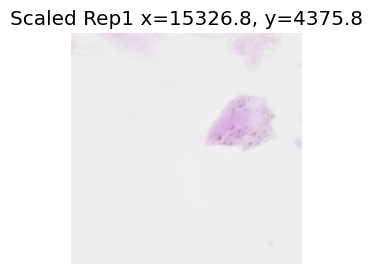

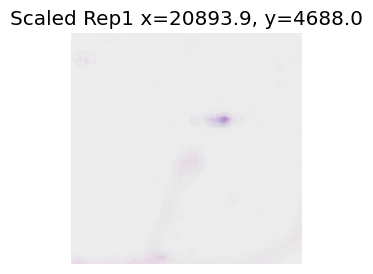

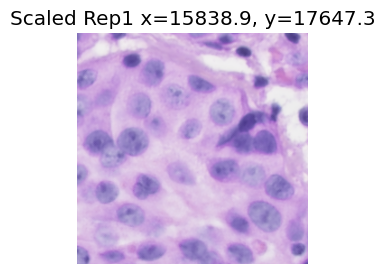

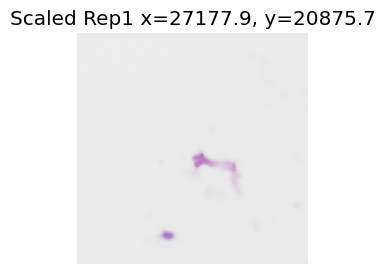

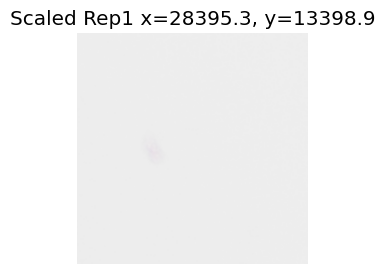

In [82]:
import matplotlib.pyplot as plt
import random

for i in random.sample(range(len(train_xy_scaled)), 5):
    x, y = train_xy_scaled[i]
    patch = img1.crop(x, y, size=256)

    plt.figure(figsize=(3,3))
    plt.imshow(patch)
    plt.axis("off")
    plt.title(f"Scaled Rep1 x={x:.1f}, y={y:.1f}")
    plt.show()

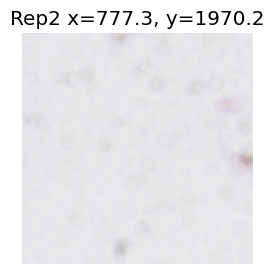

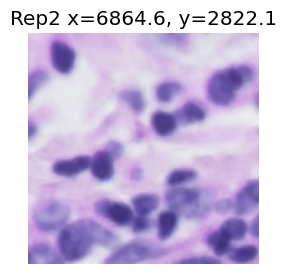

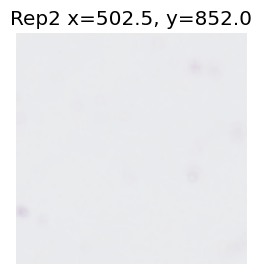

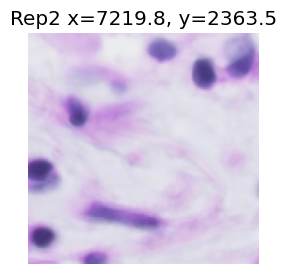

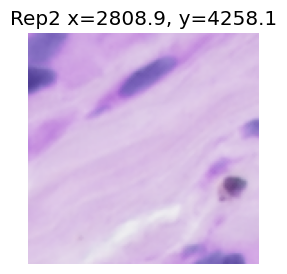

In [83]:
for i in random.sample(range(len(test_xy)), 5):
    x, y = test_xy[i]
    patch = img2.crop(x, y, size=128)

    plt.figure(figsize=(3,3))
    plt.imshow(patch)
    plt.axis("off")
    plt.title(f"Rep2 x={x:.1f}, y={y:.1f}")
    plt.show()

In [84]:
# ============================
# Dataset + DataLoaders with filtered patches + Rep1 internal validation
# ============================

from sklearn.model_selection import train_test_split

def is_valid_patch(patch, white_thresh=0.70, min_std=0.07, black_thresh=0.10):
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
    gray = gray.astype(np.float32) / 255.0

    white_ratio = np.mean(gray > 0.90)
    black_ratio = np.mean(gray < 0.05)
    std_value = np.std(gray)

    return (
        white_ratio < white_thresh
        and black_ratio < black_thresh
        and std_value > min_std
    )


def filter_cells_by_patch_quality(
    coords,
    he_img,
    y,
    neigh_y,
    patch_size=512,
    white_thresh=0.70,
    min_std=0.07,
    black_thresh=0.10
):
    valid_idx = []

    for i in range(len(coords)):
        x, ycoord = coords[i]
        patch = he_img.crop(x, ycoord, size=patch_size)

        if is_valid_patch(
            patch,
            white_thresh=white_thresh,
            min_std=min_std,
            black_thresh=black_thresh
        ):
            valid_idx.append(i)

    valid_idx = np.array(valid_idx)

    print("Before filtering:", len(coords))
    print("After filtering :", len(valid_idx))
    print("Kept ratio      :", round(len(valid_idx) / len(coords), 4))

    return (
        coords[valid_idx],
        y[valid_idx],
        neigh_y[valid_idx],
        valid_idx
    )


# ============================
# Filter bad / blank patches
# ============================

train_xy_f, train_y_f, train_neigh_f, train_valid_idx = filter_cells_by_patch_quality(
    coords=train_xy_scaled,
    he_img=img1,
    y=train_y_scaled,
    neigh_y=train_neigh_scaled,
    patch_size=512,
    white_thresh=0.75,
    min_std=0.05,
    black_thresh=0.15
)

test_xy_f, test_y_f, test_neigh_f, test_valid_idx = filter_cells_by_patch_quality(
    coords=test_xy_scaled,
    he_img=img2,
    y=test_y_scaled,
    neigh_y=test_neigh_scaled,
    patch_size=512,
    white_thresh=0.75,
    min_std=0.05,
    black_thresh=0.15
)


# ============================
# Dataset class with ImageNet normalization
# ============================

class XeniumSingleCellDataset(Dataset):
    def __init__(
        self,
        he_img,
        coords,
        y,
        neigh_y,
        patch_size=512,
        image_size=224,
        augment=False
    ):
        self.he_img = he_img
        self.coords = coords
        self.y = y
        self.neigh_y = neigh_y
        self.patch_size = patch_size
        self.image_size = image_size
        self.augment = augment

        self.imagenet_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.imagenet_std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.y)

    def augment_patch(self, patch):
        if random.random() < 0.5:
            patch = np.flip(patch, axis=1).copy()

        if random.random() < 0.5:
            patch = np.flip(patch, axis=0).copy()

        k = random.choice([0, 1, 2, 3])
        patch = np.rot90(patch, k).copy()

        return patch

    def __getitem__(self, idx):
        x, ycoord = self.coords[idx]

        patch = self.he_img.crop(
            x,
            ycoord,
            size=self.patch_size
        )

        if self.augment:
            patch = self.augment_patch(patch)

        patch = cv2.resize(
            patch,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
        )

        patch = patch.astype(np.float32) / 255.0

        # Correct normalization for pretrained ResNet/timm backbone
        patch = (patch - self.imagenet_mean) / self.imagenet_std

        patch = np.transpose(patch, (2, 0, 1))

        gene = self.y[idx].astype(np.float32)
        neigh = self.neigh_y[idx].astype(np.float32)

        return (
            torch.from_numpy(patch),
            torch.from_numpy(gene),
            torch.from_numpy(neigh)
        )


# ============================
# First experiment: Rep1 internal split
# Do this before Rep1 -> Rep2 cross-dataset testing
# ============================

idx_train, idx_val = train_test_split(
    np.arange(len(train_xy_f)),
    test_size=0.20,
    random_state=42,
    shuffle=True
)

train_ds = XeniumSingleCellDataset(
    he_img=img1,
    coords=train_xy_f[idx_train],
    y=train_y_f[idx_train],
    neigh_y=train_neigh_f[idx_train],
    patch_size=512,
    image_size=224,
    augment=True
)

test_ds = XeniumSingleCellDataset(
    he_img=img1,
    coords=train_xy_f[idx_val],
    y=train_y_f[idx_val],
    neigh_y=train_neigh_f[idx_val],
    patch_size=512,
    image_size=224,
    augment=False
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Rep1 internal train samples:", len(train_ds))
print("Rep1 internal val samples  :", len(test_ds))

imgs, genes, neigh = next(iter(train_loader))

print("Image batch:", imgs.shape)
print("Gene batch :", genes.shape)
print("Neighbor batch:", neigh.shape)

Before filtering: 167780
After filtering : 95351
Kept ratio      : 0.5683
Before filtering: 118752
After filtering : 81934
Kept ratio      : 0.69
Rep1 internal train samples: 76280
Rep1 internal val samples  : 19071
Image batch: torch.Size([32, 3, 224, 224])
Gene batch : torch.Size([32, 100])
Neighbor batch: torch.Size([32, 100])


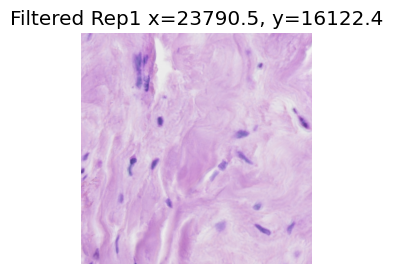

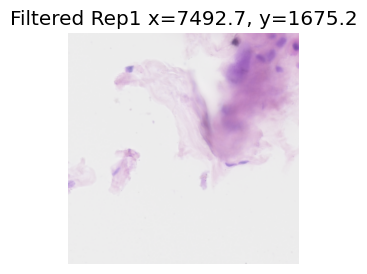

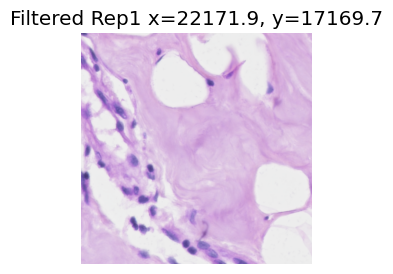

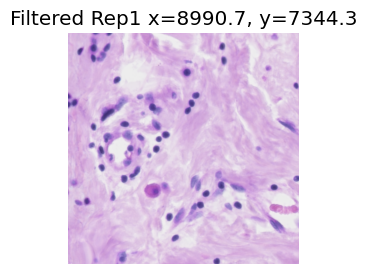

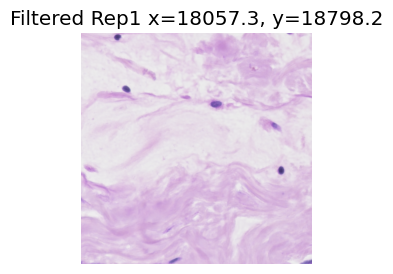

In [87]:
for i in random.sample(range(len(train_xy_f)), 5):
    x, y = train_xy_f[i]
    patch = img1.crop(x, y, size=512)

    plt.figure(figsize=(3,3))
    plt.imshow(patch)
    plt.axis("off")
    plt.title(f"Filtered Rep1 x={x:.1f}, y={y:.1f}")
    plt.show()

In [88]:
class StrongGHISTStyleNet(nn.Module):
    def __init__(self, n_genes):
        super().__init__()

        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )

        feat_dim = self.backbone.num_features

        self.shared = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.10)
        )

        self.gene_head = nn.Linear(256, n_genes)
        self.neighborhood_head = nn.Linear(256, n_genes)

        self.morphology_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Linear(64, 16)
        )

    def forward(self, x):
        z = self.backbone(x)
        z = self.shared(z)

        gene = self.gene_head(z)
        neigh = self.neighborhood_head(z)
        morph = self.morphology_head(z)

        return gene, neigh, morph


model = StrongGHISTStyleNet(n_genes=len(hvgs)).to(device)

for p in model.backbone.parameters():
    p.requires_grad = False

# For 50 genes: unfreeze ONLY final ConvNeXt stage
for name, p in model.backbone.named_parameters():
    if "stages.3" in name:
        p.requires_grad = True

print("ConvNeXt-Tiny loaded")
print("Number of HVGs:", len(hvgs))
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6, "M")

ConvNeXt-Tiny loaded
Number of HVGs: 100
Trainable parameters: 16.066072 M


In [90]:
def pearson_loss(pred, target, eps=1e-6):
    pred = pred - pred.mean(dim=0, keepdim=True)
    target = target - target.mean(dim=0, keepdim=True)

    pred = pred / (pred.std(dim=0, keepdim=True) + eps)
    target = target / (target.std(dim=0, keepdim=True) + eps)

    corr = (pred * target).mean(dim=0)
    corr = torch.clamp(corr, -1.0, 1.0)

    return 1.0 - corr.mean()


def ghist_loss(pred_gene, true_gene, pred_neigh, true_neigh, morph):

    # -------- Gene loss (MAIN FOCUS = PCC) --------
    gene_l1 = F.smooth_l1_loss(pred_gene, true_gene)
    gene_corr = pearson_loss(pred_gene, true_gene)

    # 🔥 Key change: PCC dominates
    gene_loss = 0.3 * gene_l1 + 1.0 * gene_corr

    # -------- Neighbor loss (support signal) --------
    neigh_l1 = F.smooth_l1_loss(pred_neigh, true_neigh)
    neigh_corr = pearson_loss(pred_neigh, true_neigh)

    neigh_loss = 0.2 * neigh_l1 + 0.5 * neigh_corr

    # -------- Morphology regularization --------
    morph_loss = 0.00005 * torch.mean(morph ** 2)

    # -------- Total loss --------
    total_loss = gene_loss + 0.15 * neigh_loss + morph_loss

    return total_loss, gene_loss, neigh_loss, morph_loss

In [91]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
    mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())

    gene_pccs = []

    for g in range(y_true.shape[1]):
        a = y_true[:, g]
        b = y_pred[:, g]

        if np.std(a) > 1e-8 and np.std(b) > 1e-8:
            pcc = np.corrcoef(a, b)[0, 1]

            if not np.isnan(pcc):
                gene_pccs.append(pcc)

    if len(gene_pccs) == 0:
        mean_pcc = 0.0
        median_pcc = 0.0
    else:
        mean_pcc = float(np.mean(gene_pccs))
        median_pcc = float(np.median(gene_pccs))

    return {
        "RMSE": float(rmse),
        "MAE": float(mae),
        "Mean_PCC": mean_pcc,
        "Median_PCC": median_pcc,
        "Evaluated_Genes": len(gene_pccs)
    }

In [92]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
    betas=(0.9, 0.999),
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

EPOCHS = 15
best_pcc = -999

history = []

for epoch in range(1, EPOCHS + 1):

    print("\n" + "="*70)
    print(f"Epoch {epoch}/{EPOCHS}")
    print("="*70)

    model.train()

    total_loss = 0.0
    total_gene_loss = 0.0
    total_neigh_loss = 0.0
    total_morph_loss = 0.0

    for imgs, genes, neigh in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        genes = genes.to(device, non_blocking=True)
        neigh = neigh.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            pred_gene, pred_neigh, morph = model(imgs)
            loss, gene_loss, neigh_loss, morph_loss = ghist_loss(
                pred_gene, genes, pred_neigh, neigh, morph
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_gene_loss += gene_loss.item()
        total_neigh_loss += neigh_loss.item()
        total_morph_loss += morph_loss.item()

    avg_loss = total_loss / len(train_loader)
    avg_gene_loss = total_gene_loss / len(train_loader)
    avg_neigh_loss = total_neigh_loss / len(train_loader)
    avg_morph_loss = total_morph_loss / len(train_loader)

    print("Validation started...")

    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for imgs, genes, neigh in test_loader:
            imgs = imgs.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                pred_gene, _, _ = model(imgs)

            preds.append(pred_gene.float().cpu().numpy())
            trues.append(genes.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    preds_real = preds * gene_std + gene_mean
    trues_real = trues * gene_std + gene_mean

    metrics = compute_metrics(trues_real, preds_real)

    scheduler.step(metrics["Mean_PCC"])

    print("\nEpoch Summary")
    print("Train Loss      :", round(avg_loss, 4))
    print("Gene Loss       :", round(avg_gene_loss, 4))
    print("Neighbor Loss   :", round(avg_neigh_loss, 4))
    print("Morph Loss      :", round(avg_morph_loss, 6))
    print("Mean PCC        :", round(metrics["Mean_PCC"], 4))
    print("Median PCC      :", round(metrics["Median_PCC"], 4))
    print("Evaluated Genes :", metrics.get("Evaluated_Genes", len(hvgs)))
    print("RMSE            :", round(metrics["RMSE"], 4))
    print("MAE             :", round(metrics["MAE"], 4))
    print("LR              :", optimizer.param_groups[0]["lr"])
    print("Best PCC So Far :", round(best_pcc, 4))

    history.append({
        "epoch": epoch,
        "train_loss": avg_loss,
        "gene_loss": avg_gene_loss,
        "neighbor_loss": avg_neigh_loss,
        "morph_loss": avg_morph_loss,
        "mean_pcc": metrics["Mean_PCC"],
        "median_pcc": metrics["Median_PCC"],
        "evaluated_genes": metrics.get("Evaluated_Genes", len(hvgs)),
        "rmse": metrics["RMSE"],
        "mae": metrics["MAE"],
        "lr": optimizer.param_groups[0]["lr"]
    })

    if metrics["Mean_PCC"] > best_pcc:
        best_pcc = metrics["Mean_PCC"]

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "hvgs": hvgs,
                "gene_mean": gene_mean,
                "gene_std": gene_std,
                "best_pcc": best_pcc,
                "metrics": metrics
            },
            "/kaggle/working/best_convnext_150hvg_ghist_model.pt"
        )

        print("Status: Best model saved")
    else:
        print("Status: Continued training")


history_df = pd.DataFrame(history)
history_df.to_csv("/kaggle/working/convnext_150hvg_ghist_training_history.csv", index=False)

print("\nTraining finished")
print("Best Mean PCC:", best_pcc)
print("History saved: /kaggle/working/convnext_150hvg_ghist_training_history.csv")
print("Best model saved: /kaggle/working/best_convnext_150hvg_ghist_model.pt")


Epoch 1/15
Validation started...

Epoch Summary
Train Loss      : 0.8674
Gene Loss       : 0.8205
Neighbor Loss   : 0.3129
Morph Loss      : 0.0
Mean PCC        : 0.4117
Median PCC      : 0.3926
Evaluated Genes : 100
RMSE            : 2.1334
MAE             : 1.5263
LR              : 5e-05
Best PCC So Far : -999
Status: Best model saved

Epoch 2/15
Validation started...

Epoch Summary
Train Loss      : 0.71
Gene Loss       : 0.6802
Neighbor Loss   : 0.1992
Morph Loss      : 0.0
Mean PCC        : 0.4752
Median PCC      : 0.4457
Evaluated Genes : 100
RMSE            : 2.0132
MAE             : 1.4388
LR              : 5e-05
Best PCC So Far : 0.4117
Status: Best model saved

Epoch 3/15
Validation started...

Epoch Summary
Train Loss      : 0.6633
Gene Loss       : 0.638
Neighbor Loss   : 0.1684
Morph Loss      : 0.0
Mean PCC        : 0.4923
Median PCC      : 0.461
Evaluated Genes : 100
RMSE            : 1.9935
MAE             : 1.409
LR              : 5e-05
Best PCC So Far : 0.4752
Status

In [93]:
gene_pccs = []

for g in range(trues_real.shape[1]):
    a = trues_real[:, g]
    b = preds_real[:, g]

    if np.std(a) > 1e-8 and np.std(b) > 1e-8:
        pcc = np.corrcoef(a, b)[0, 1]
    else:
        pcc = 0.0

    gene_pccs.append(pcc)

gene_pccs = np.array(gene_pccs)

top_idx = np.argsort(gene_pccs)[::-1][:100]
top_genes = [hvgs[i] for i in top_idx]

print("Top 100 predictable genes:")
print(top_genes[:30])
print("Mean PCC top 100:", gene_pccs[top_idx].mean())

np.save("/kaggle/working/top100_gene_idx.npy", top_idx)
pd.DataFrame({
    "gene": hvgs,
    "pcc": gene_pccs
}).sort_values("pcc", ascending=False).to_csv(
    "/kaggle/working/gene_predictability.csv",
    index=False
)

Top 100 predictable genes:
['KRT7', 'FASN', 'FOXA1', 'EPCAM', 'KRT8', 'MLPH', 'TACSTD2', 'SCD', 'LUM', 'CCDC80', 'POSTN', 'CXCL12', 'GATA3', 'CEACAM6', 'CD9', 'CDH1', 'ANKRD30A', 'ABCC11', 'KRT14', 'ERBB2', 'MYO5B', 'PTGDS', 'DSP', 'SFRP4', 'MMP2', 'KRT5', 'CCND1', 'SERHL2', 'SERPINA3', 'SFRP1']
Mean PCC top 100: 0.5476807572893909


In [24]:
df = pd.read_csv("/kaggle/working/gene_predictability.csv")

top_genes = df.sort_values("pcc", ascending=False)["gene"].values[:100]

hvgs = list(top_genes)

print("Using top predictable genes:", len(hvgs))
print("Example genes:", hvgs[:10])

Using top predictable genes: 100
Example genes: ['KRT7', 'FASN', 'FOXA1', 'EPCAM', 'KRT8', 'MLPH', 'TACSTD2', 'SCD', 'LUM', 'CCDC80']


In [94]:
checkpoint = torch.load(
    "/kaggle/working/best_convnext_150hvg_ghist_model.pt",
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best model")
print("Best PCC:", checkpoint["best_pcc"])
print("Epoch:", checkpoint["epoch"])

Loaded best model
Best PCC: 0.5476807572893909
Epoch: 15


In [95]:
model.eval()

preds = []
trues = []

with torch.no_grad():
    for imgs, genes, neigh in test_loader:
        imgs = imgs.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            pred_gene, _, _ = model(imgs)

        preds.append(pred_gene.float().cpu().numpy())
        trues.append(genes.cpu().numpy())

preds = np.concatenate(preds, axis=0)
trues = np.concatenate(trues, axis=0)

preds_real = preds * gene_std + gene_mean
trues_real = trues * gene_std + gene_mean

final_metrics = compute_metrics(trues_real, preds_real)

print("Final Evaluation Metrics")
print(final_metrics)

Final Evaluation Metrics
{'RMSE': 1.9079885215693912, 'MAE': 1.307430624961853, 'Mean_PCC': 0.5476807572893909, 'Median_PCC': 0.5227874115358513, 'Evaluated_Genes': 100}


In [27]:
gene_reports = []

for i, gene in enumerate(hvgs):
    y_true = trues_real[:, i]
    y_pred = preds_real[:, i]

    if np.std(y_true) > 1e-8 and np.std(y_pred) > 1e-8:
        pcc = np.corrcoef(y_true, y_pred)[0, 1]
    else:
        pcc = 0.0

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    gene_reports.append({
        "Gene": gene,
        "PCC": pcc,
        "RMSE": rmse,
        "MAE": mae
    })

gene_report_df = pd.DataFrame(gene_reports)
gene_report_df = gene_report_df.sort_values("PCC", ascending=False)

gene_report_df.to_csv("/kaggle/working/final_gene_level_report.csv", index=False)

print(gene_report_df.head(20))

        Gene       PCC      RMSE       MAE
36     LYPD3  0.706545  1.900064  1.399449
84    SH3YL1  0.700447  1.943546  1.452003
63       CD4  0.695784  1.777640  1.304387
66    S100A4  0.690092  1.796829  1.401406
65      KLF5  0.687684  1.780572  1.294422
16  ANKRD30A  0.681919  1.922704  1.439215
0       KRT7  0.669419  1.711473  1.179998
40      ELF3  0.650983  1.772058  1.248426
97    FCER1G  0.646495  1.782159  1.285513
22       DSP  0.572621  1.708041  1.220289
82    ADIPOQ  0.551621  1.937322  1.455491
5       MLPH  0.532354  1.332548  0.652058
7        SCD  0.523594  1.056714  0.482108
87       SMS  0.508791  2.218109  1.854307
89    SLC5A6  0.503265  1.788619  1.215142
51      TRAC  0.501252  1.899231  1.269268
53     CXCR4  0.480700  2.057012  1.603332
70      TCF4  0.465366  1.621127  1.156282
33     KRT15  0.461804  1.854394  1.279959
98      MDM2  0.448528  2.102945  1.677559


In [28]:
summary_report = pd.DataFrame([{
    "Mean PCC": final_metrics["Mean_PCC"],
    "Median PCC": final_metrics["Median_PCC"],
    "RMSE": final_metrics["RMSE"],
    "MAE": final_metrics["MAE"],
    "Evaluated Genes": final_metrics["Evaluated_Genes"],
    "Best Checkpoint PCC": checkpoint["best_pcc"],
    "Best Epoch": checkpoint["epoch"]
}])

summary_report.to_csv("/kaggle/working/final_model_summary_report.csv", index=False)

print(summary_report)

   Mean PCC  Median PCC      RMSE       MAE  Evaluated Genes  \
0  0.333734    0.307235  1.483593  0.849568              300   

   Best Checkpoint PCC  Best Epoch  
0             0.333734          13  


In [29]:
plt.rcParams["font.family"] = "DejaVu Sans"

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

Saved figure: /kaggle/working/Figure_Training_PCC_Curve.png


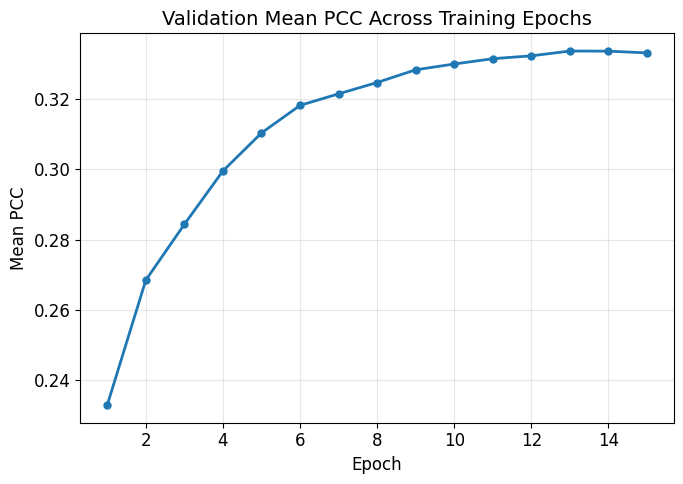

In [30]:
# ============================================================
# Training PCC Curve
# Save as 400 DPI PNG in Kaggle working directory
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load history
history_df = pd.read_csv(
    "/kaggle/working/convnext_150hvg_ghist_training_history.csv"
)

# Figure style
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12

# Create figure
plt.figure(figsize=(7, 5))

plt.plot(
    history_df["epoch"],
    history_df["mean_pcc"],
    marker="o",
    linewidth=2,
    markersize=5
)

# Labels
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Mean PCC", fontsize=12)

# Title
plt.title(
    "Validation Mean PCC Across Training Epochs",
    fontsize=14
)

# Grid
plt.grid(alpha=0.3)

# Tight layout
plt.tight_layout()

# Save
save_path = "/kaggle/working/Figure_Training_PCC_Curve.png"

plt.savefig(
    save_path,
    dpi=400,
    bbox_inches="tight"
)

print("Saved figure:", save_path)

# Show
plt.show()

Saved figure: /kaggle/working/Figure_Top30_Gene_PCC.png


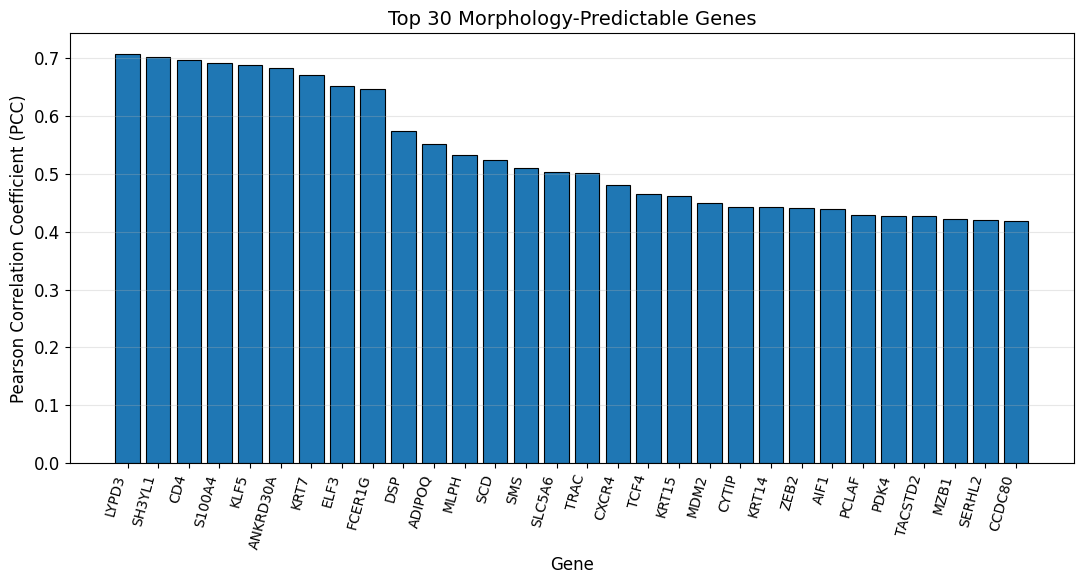

In [31]:
# ============================================================
# Top 30 Gene PCC Bar Plot
# Save as 400 DPI PNG in Kaggle working directory
# Font-safe version
# ============================================================

import matplotlib.pyplot as plt
import matplotlib

# Safe font (avoids Times New Roman warnings on Kaggle)
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# Select top genes
top_plot = gene_report_df.head(30)

# Create figure
plt.figure(figsize=(11, 6))

plt.bar(
    top_plot["Gene"],
    top_plot["PCC"],
    edgecolor="black",
    linewidth=0.8
)

# Labels
plt.xlabel("Gene", fontsize=12)
plt.ylabel("Pearson Correlation Coefficient (PCC)", fontsize=12)

# Title
plt.title(
    "Top 30 Morphology-Predictable Genes",
    fontsize=14
)

# Rotate x labels
plt.xticks(
    rotation=75,
    ha="right",
    fontsize=10
)

# Grid
plt.grid(axis="y", alpha=0.3)

# Tight layout
plt.tight_layout()

# Save
save_path = "/kaggle/working/Figure_Top30_Gene_PCC.png"

plt.savefig(
    save_path,
    dpi=400,
    bbox_inches="tight"
)

print("Saved figure:", save_path)

# Show
plt.show()

Saved: /kaggle/working/Figure_Scatter_LYPD3.png


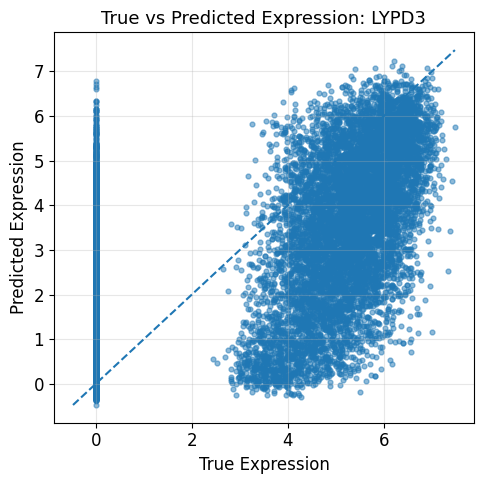

Saved: /kaggle/working/Figure_Scatter_SH3YL1.png


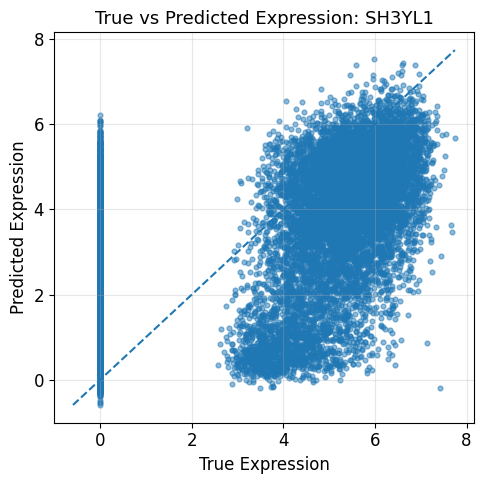

Saved: /kaggle/working/Figure_Scatter_CD4.png


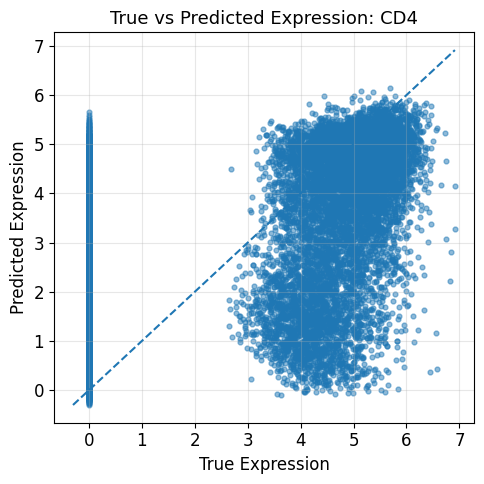

Saved: /kaggle/working/Figure_Scatter_S100A4.png


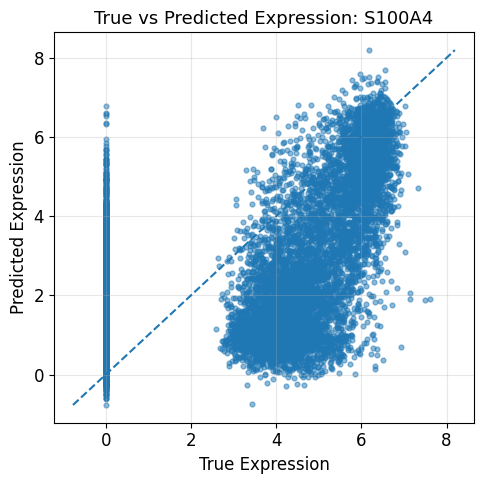

Saved: /kaggle/working/Figure_Scatter_KLF5.png


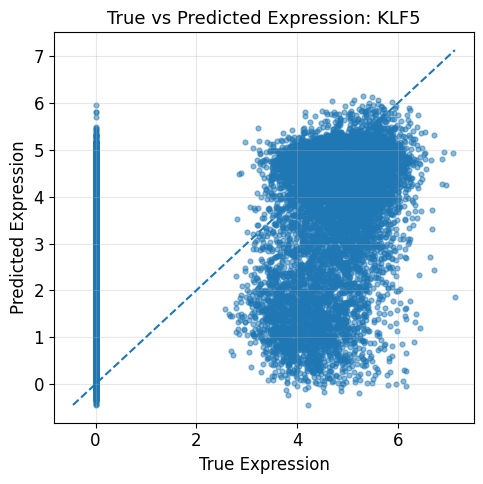

In [32]:
# ============================================================
# True vs Predicted Scatter Plots
# Save each figure as 400 DPI PNG
# ============================================================

import matplotlib.pyplot as plt
import matplotlib

# Safe font for Kaggle
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# Top genes
best_genes = gene_report_df.head(5)["Gene"].tolist()

for gene in best_genes:

    idx = hvgs.index(gene)

    y_true = trues_real[:, idx]
    y_pred = preds_real[:, idx]

    # Create figure
    plt.figure(figsize=(5, 5))

    plt.scatter(
        y_true,
        y_pred,
        alpha=0.5,
        s=12
    )

    # Identity line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=1.5
    )

    # Labels
    plt.xlabel("True Expression", fontsize=12)
    plt.ylabel("Predicted Expression", fontsize=12)

    # Title
    plt.title(
        f"True vs Predicted Expression: {gene}",
        fontsize=13
    )

    # Grid
    plt.grid(alpha=0.3)

    # Tight layout
    plt.tight_layout()

    # Save
    save_path = f"/kaggle/working/Figure_Scatter_{gene}.png"

    plt.savefig(
        save_path,
        dpi=400,
        bbox_inches="tight"
    )

    print(f"Saved: {save_path}")

    # Show
    plt.show()

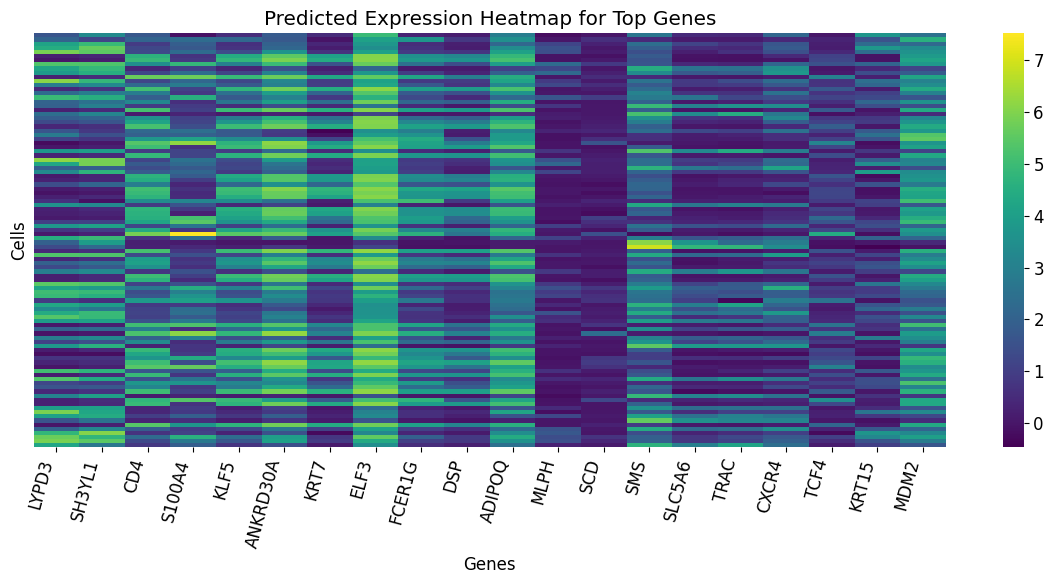

In [33]:
import seaborn as sns

selected_genes = gene_report_df.head(20)["Gene"].tolist()
selected_idx = [hvgs.index(g) for g in selected_genes]

plt.figure(figsize=(12, 6))
sns.heatmap(
    preds_real[:100, selected_idx],
    cmap="viridis",
    xticklabels=selected_genes,
    yticklabels=False
)
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Predicted Expression Heatmap for Top Genes")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig("/kaggle/working/fig_predicted_expression_heatmap.png", dpi=400, bbox_inches="tight")
plt.show()

In [34]:
# ============================================================
# Correct evaluation coordinates
# ============================================================

eval_coords = test_ds.coords

print("Eval coords:", eval_coords.shape)
print("Prediction values:", trues_real.shape)

assert eval_coords.shape[0] == trues_real.shape[0], "Coordinate and prediction size mismatch!"

Eval coords: (19071, 2)
Prediction values: (19071, 300)


In [35]:
# ============================================================
# Spatial plotting function
# ============================================================

def plot_spatial_gene(coords, values, title, save_path):
    coords = np.asarray(coords)
    values = np.asarray(values)

    print("Coords:", coords.shape)
    print("Values:", values.shape)
    print("Value range:", values.min(), values.max())

    assert coords.shape[0] == values.shape[0], "coords and values must have same length"

    plt.figure(figsize=(6, 6))

    sc_plot = plt.scatter(
        coords[:, 0],
        coords[:, 1],
        c=values,
        s=4,
        cmap="viridis",
        alpha=0.85,
        linewidths=0
    )

    plt.gca().invert_yaxis()
    plt.colorbar(sc_plot, label="Expression")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=500, bbox_inches="tight")
    plt.show()

Coords: (19071, 2)
Values: (19071,)
Saved: /kaggle/working/Figure_True_KRT7.png


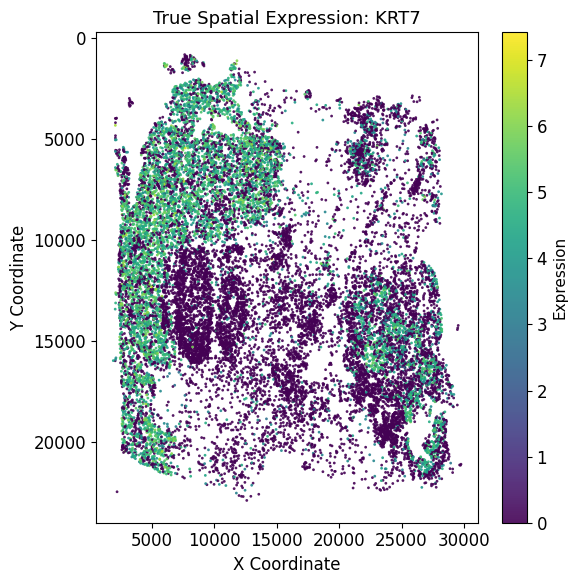

Coords: (19071, 2)
Values: (19071,)
Saved: /kaggle/working/Figure_Predicted_KRT7.png


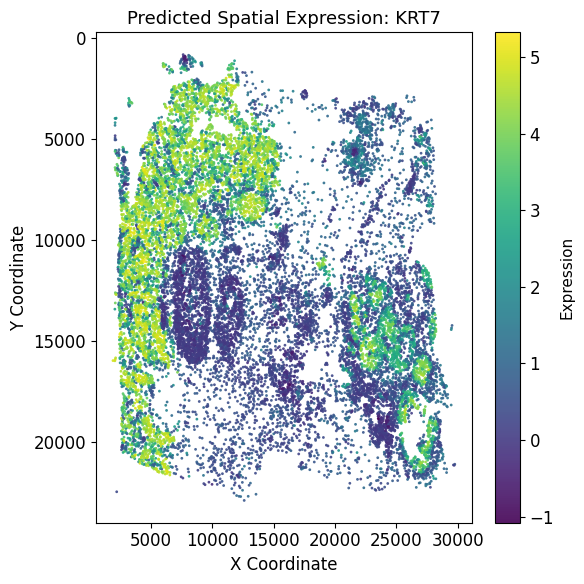

Coords: (19071, 2)
Values: (19071,)
Saved: /kaggle/working/Figure_Error_KRT7.png


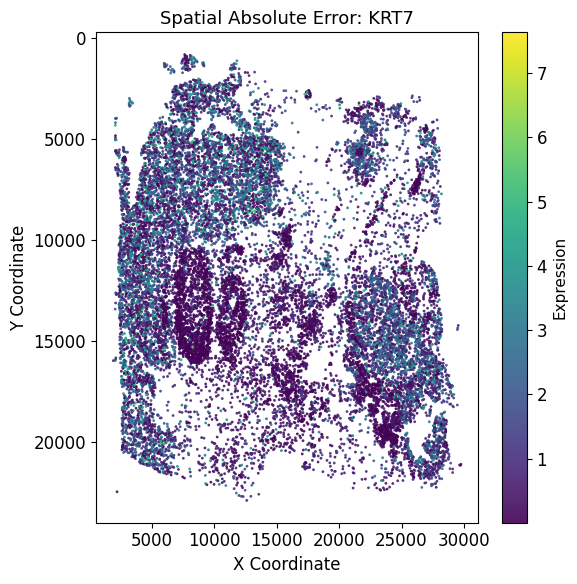

In [36]:
# ============================================================
# Spatial Expression Visualization
# Save as 400 DPI PNG in Kaggle working directory
# ============================================================

import matplotlib.pyplot as plt
import matplotlib

# Safe font for Kaggle
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ============================================================
# Spatial plotting function
# ============================================================

def plot_spatial_gene(coords, values, title, save_path):

    coords = np.asarray(coords)
    values = np.asarray(values)

    print("Coords:", coords.shape)
    print("Values:", values.shape)

    assert coords.shape[0] == values.shape[0], \
        "coords and values must have same length"

    plt.figure(figsize=(6, 6))

    sc_plot = plt.scatter(
        coords[:, 0],
        coords[:, 1],
        c=values,
        s=4,
        cmap="viridis",
        alpha=0.9,
        linewidths=0
    )

    plt.gca().invert_yaxis()

    cbar = plt.colorbar(sc_plot)
    cbar.set_label("Expression", fontsize=11)

    plt.xlabel("X Coordinate", fontsize=12)
    plt.ylabel("Y Coordinate", fontsize=12)

    plt.title(title, fontsize=13)

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=400,
        bbox_inches="tight"
    )

    print("Saved:", save_path)

    plt.show()


# ============================================================
# Example Gene Visualization
# ============================================================

gene_name = "KRT7"

g = hvgs.index(gene_name)

# TRUE expression
plot_spatial_gene(
    coords=eval_coords,
    values=trues_real[:, g],
    title=f"True Spatial Expression: {gene_name}",
    save_path=f"/kaggle/working/Figure_True_{gene_name}.png"
)

# PREDICTED expression
plot_spatial_gene(
    coords=eval_coords,
    values=preds_real[:, g],
    title=f"Predicted Spatial Expression: {gene_name}",
    save_path=f"/kaggle/working/Figure_Predicted_{gene_name}.png"
)

# ABSOLUTE ERROR
plot_spatial_gene(
    coords=eval_coords,
    values=np.abs(trues_real[:, g] - preds_real[:, g]),
    title=f"Spatial Absolute Error: {gene_name}",
    save_path=f"/kaggle/working/Figure_Error_{gene_name}.png"
)

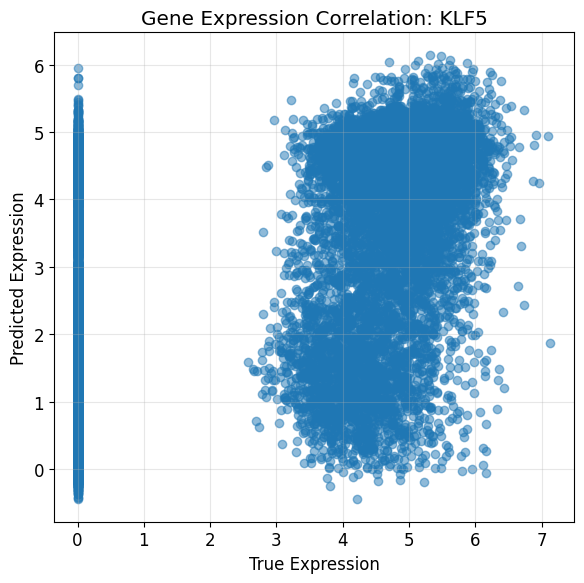

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(
    trues_real[:, idx],
    preds_real[:, idx],
    alpha=0.5
)
plt.xlabel("True Expression")
plt.ylabel("Predicted Expression")
plt.title(f"Gene Expression Correlation: {gene}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"/kaggle/working/correlation_{gene}.png", dpi=400)
plt.show()

In [38]:
# ============================================================
# Q1-Level Evaluation Setup
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr

# Save directory
SAVE_DIR = "/kaggle/working/final_evaluation_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# Kaggle-safe font
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.size"] = 12
matplotlib.rcParams["axes.linewidth"] = 1.2

print("Evaluation setup complete.")
print("Figures will be saved in:", SAVE_DIR)
print("Current files:", os.listdir(SAVE_DIR)[:10])

Evaluation setup complete.
Figures will be saved in: /kaggle/working/final_evaluation_figures
Current files: []


Saved: /kaggle/working/Figure_Training_PCC_Curve.png


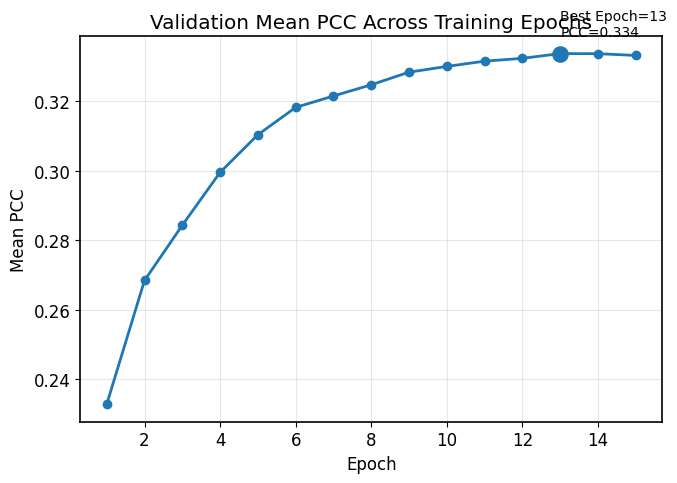

In [39]:
# ============================================================
# REAL Training PCC Curve
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "DejaVu Sans"

# load history
history_df = pd.read_csv(
    "/kaggle/working/convnext_150hvg_ghist_training_history.csv"
)

plt.figure(figsize=(7,5))

plt.plot(
    history_df["epoch"],
    history_df["mean_pcc"],
    marker="o",
    linewidth=2
)

# highlight best epoch
best_idx = history_df["mean_pcc"].idxmax()

best_epoch = history_df.loc[best_idx, "epoch"]
best_pcc = history_df.loc[best_idx, "mean_pcc"]

plt.scatter(
    best_epoch,
    best_pcc,
    s=120
)

plt.text(
    best_epoch,
    best_pcc + 0.005,
    f"Best Epoch={best_epoch}\nPCC={best_pcc:.3f}",
    fontsize=10
)

plt.xlabel("Epoch")
plt.ylabel("Mean PCC")
plt.title("Validation Mean PCC Across Training Epochs")

plt.grid(alpha=0.3)

plt.tight_layout()

save_path = "/kaggle/working/Figure_Training_PCC_Curve.png"

plt.savefig(
    save_path,
    dpi=400,
    bbox_inches="tight"
)

print("Saved:", save_path)

plt.show()

In [40]:
# ============================================================
# Load Best Checkpoint - PyTorch 2.6 compatible
# ============================================================

ckpt_path = "/kaggle/working/best_convnext_150hvg_ghist_model.pt"

checkpoint = torch.load(
    ckpt_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded checkpoint:", ckpt_path)
print("Best PCC:", checkpoint.get("best_pcc", "N/A"))
print("Checkpoint epoch:", checkpoint.get("epoch", "N/A"))

Loaded checkpoint: /kaggle/working/best_convnext_150hvg_ghist_model.pt
Best PCC: 0.33373445845467176
Checkpoint epoch: 13


In [41]:
# ============================================================
# Prediction Collection
# ============================================================

preds = []
trues = []

model.eval()

with torch.no_grad():
    for imgs, genes, neigh in test_loader:
        imgs = imgs.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            pred_gene, _, _ = model(imgs)

        preds.append(pred_gene.float().cpu().numpy())
        trues.append(genes.cpu().numpy())

preds = np.concatenate(preds, axis=0)
trues = np.concatenate(trues, axis=0)

preds_real = preds * gene_std + gene_mean
trues_real = trues * gene_std + gene_mean

print("Prediction shape:", preds_real.shape)
print("Ground truth shape:", trues_real.shape)

Prediction shape: (19071, 300)
Ground truth shape: (19071, 300)


History loaded: (15, 11)
Saved: /kaggle/working/final_evaluation_figures/Figure_Training_Loss_Curve.png


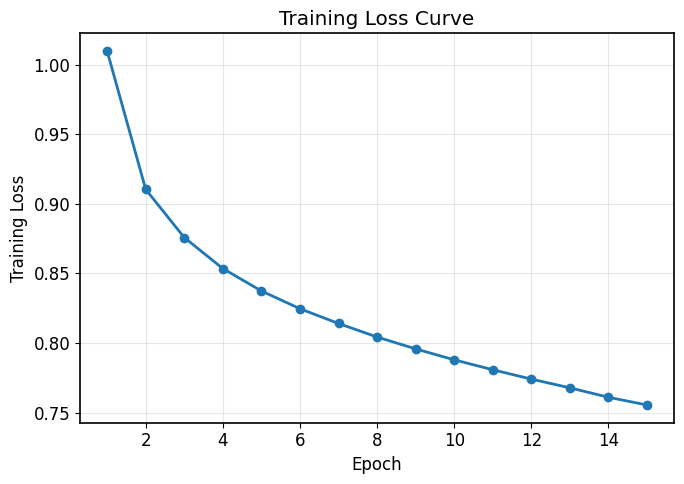

Saved: /kaggle/working/final_evaluation_figures/Figure_Validation_PCC_Curve.png


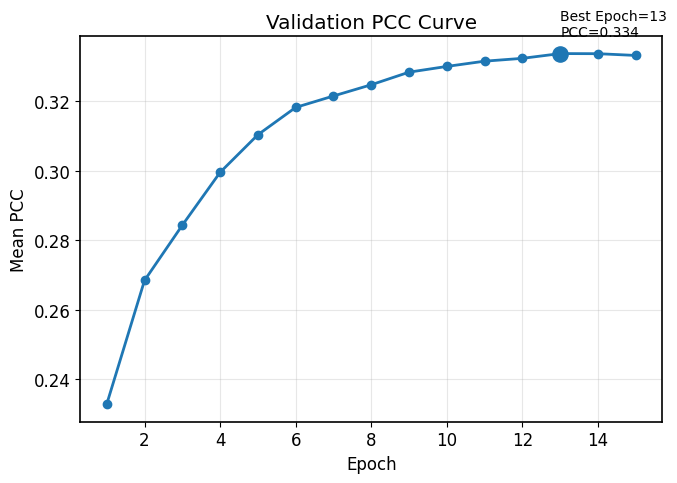

Saved: /kaggle/working/final_evaluation_figures/Figure_Validation_RMSE_Curve.png


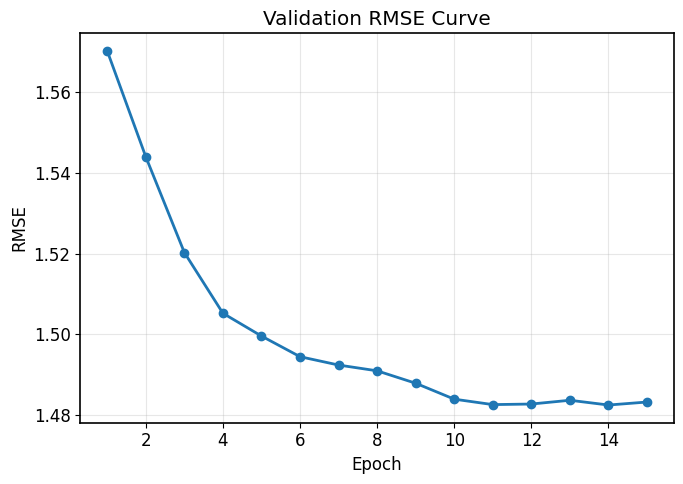

In [42]:
# ============================================================
# Training Curves (400 DPI PNG)
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# ------------------------------------------------------------
# Kaggle-safe font
# ------------------------------------------------------------

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.size"] = 12
matplotlib.rcParams["axes.linewidth"] = 1.2

# ------------------------------------------------------------
# Load history
# ------------------------------------------------------------

history_path = "/kaggle/working/convnext_150hvg_ghist_training_history.csv"

if os.path.exists(history_path):

    history_df = pd.read_csv(history_path)

    print("History loaded:", history_df.shape)

    # ========================================================
    # Training Loss Curve
    # ========================================================

    plt.figure(figsize=(7, 5))

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        linewidth=2,
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Training Loss Curve")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    save_path = f"{SAVE_DIR}/Figure_Training_Loss_Curve.png"

    plt.savefig(
        save_path,
        dpi=400,
        bbox_inches="tight"
    )

    print("Saved:", save_path)

    plt.show()

    # ========================================================
    # Validation PCC Curve
    # ========================================================

    plt.figure(figsize=(7, 5))

    plt.plot(
        history_df["epoch"],
        history_df["mean_pcc"],
        linewidth=2,
        marker="o"
    )

    # Best epoch marker
    best_idx = history_df["mean_pcc"].idxmax()

    best_epoch = history_df.loc[best_idx, "epoch"]
    best_pcc = history_df.loc[best_idx, "mean_pcc"]

    plt.scatter(
        best_epoch,
        best_pcc,
        s=120
    )

    plt.text(
        best_epoch,
        best_pcc + 0.005,
        f"Best Epoch={best_epoch}\nPCC={best_pcc:.3f}",
        fontsize=10
    )

    plt.xlabel("Epoch")
    plt.ylabel("Mean PCC")
    plt.title("Validation PCC Curve")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    save_path = f"{SAVE_DIR}/Figure_Validation_PCC_Curve.png"

    plt.savefig(
        save_path,
        dpi=400,
        bbox_inches="tight"
    )

    print("Saved:", save_path)

    plt.show()

    # ========================================================
    # Validation RMSE Curve
    # ========================================================

    plt.figure(figsize=(7, 5))

    plt.plot(
        history_df["epoch"],
        history_df["rmse"],
        linewidth=2,
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("Validation RMSE Curve")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    save_path = f"{SAVE_DIR}/Figure_Validation_RMSE_Curve.png"

    plt.savefig(
        save_path,
        dpi=400,
        bbox_inches="tight"
    )

    print("Saved:", save_path)

    plt.show()

else:
    print("Training history file not found.")

In [ ]:
# ============================================================
# Per-Gene PCC Distribution
# Save as 400 DPI PNG + Kaggle-safe font
# ============================================================

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os

# Kaggle-safe font
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.size"] = 12
matplotlib.rcParams["axes.linewidth"] = 1.2

# Make sure save directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# Convert to numpy array
gene_pccs_array = np.array(gene_pccs)

mean_pcc = np.mean(gene_pccs_array)
median_pcc = np.median(gene_pccs_array)

plt.figure(figsize=(7, 5))

plt.hist(
    gene_pccs_array,
    bins=20,
    edgecolor="black",
    alpha=0.85
)

plt.axvline(
    mean_pcc,
    linestyle="--",
    linewidth=2,
    label=f"Mean PCC = {mean_pcc:.3f}"
)

plt.axvline(
    median_pcc,
    linestyle=":",
    linewidth=2,
    label=f"Median PCC = {median_pcc:.3f}"
)

plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Number of Genes")
plt.title("Distribution of Gene-wise Prediction Correlations")

plt.legend(frameon=True)
plt.grid(alpha=0.3)

plt.tight_layout()

save_path = f"{SAVE_DIR}/Figure_Per_Gene_PCC_Distribution.png"

plt.savefig(
    save_path,
    dpi=400,
    bbox_inches="tight"
)

print("Saved:", save_path)

plt.show()

In [ ]:
# ============================================================
# Compute Per-Gene Metrics (REQUIRED BEFORE PLOTTING)
# ============================================================

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

gene_pccs = []
gene_spearmans = []
gene_rmse = []
gene_mae = []
gene_r2 = []

for g in range(trues_real.shape[1]):
    y_true = trues_real[:, g]
    y_pred = preds_real[:, g]

    if np.std(y_true) > 1e-8 and np.std(y_pred) > 1e-8:
        pcc = pearsonr(y_true, y_pred)[0]
        sp = spearmanr(y_true, y_pred)[0]
    else:
        pcc = 0.0
        sp = 0.0

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    try:
        r2 = r2_score(y_true, y_pred)
    except:
        r2 = 0.0

    gene_pccs.append(pcc)
    gene_spearmans.append(sp)
    gene_rmse.append(rmse)
    gene_mae.append(mae)
    gene_r2.append(r2)

gene_metrics_df = pd.DataFrame({
    "Gene": hvgs,
    "PCC": gene_pccs,
    "Spearman": gene_spearmans,
    "RMSE": gene_rmse,
    "MAE": gene_mae,
    "R2": gene_r2
}).sort_values("PCC", ascending=False)

print("Metrics ready ✅")
print("Mean PCC:", np.mean(gene_pccs))

In [ ]:
# ============================================================
# Top 20 Gene PCC Bar Chart
# ============================================================

top20 = gene_metrics_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["Gene"][::-1], top20["PCC"][::-1], edgecolor="black")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Gene")
plt.title("Top 20 Morphology-Predictable Genes")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/Figure_Top20_Gene_PCC_Barplot.png", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Predicted vs True Scatter Plots
# ============================================================

top_genes_to_plot = gene_metrics_df.head(6)["Gene"].tolist()

for gene in top_genes_to_plot:
    g = hvgs.index(gene)

    y_true = trues_real[:, g]
    y_pred = preds_real[:, g]
    pcc = pearsonr(y_true, y_pred)[0]

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, s=12, alpha=0.55, edgecolor="none")

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1.5)

    plt.xlabel("True Expression")
    plt.ylabel("Predicted Expression")
    plt.title(f"{gene}: True vs Predicted Expression\nPCC = {pcc:.3f}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/Figure_Scatter_{gene}.png", dpi=500, bbox_inches="tight")
    plt.show()

In [ ]:
# ============================================================
# Expression Heatmap: True vs Predicted
# ============================================================

top_genes_heatmap = gene_metrics_df.head(20)["Gene"].tolist()
top_idx = [hvgs.index(g) for g in top_genes_heatmap]

n_cells_plot = min(200, trues_real.shape[0])
sample_idx = np.random.choice(np.arange(trues_real.shape[0]), n_cells_plot, replace=False)

true_heat = trues_real[sample_idx][:, top_idx]
pred_heat = preds_real[sample_idx][:, top_idx]

combined = np.concatenate([true_heat, pred_heat], axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(
    combined,
    cmap="viridis",
    xticklabels=top_genes_heatmap,
    yticklabels=False
)
plt.axhline(n_cells_plot, color="white", linewidth=2)
plt.title("True and Predicted Gene Expression Heatmap")
plt.xlabel("Genes")
plt.ylabel("Cells: True Expression (top) / Predicted Expression (bottom)")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/Figure_True_Predicted_Expression_Heatmap.png", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Prediction Error Distribution
# ============================================================

errors = preds_real.flatten() - trues_real.flatten()

plt.figure(figsize=(7, 5))
plt.hist(errors, bins=50, edgecolor="black", alpha=0.8)
plt.axvline(0, linestyle="--", linewidth=2)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/Figure_Prediction_Error_Distribution.png", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# RMSE vs PCC Gene-Level Plot
# ============================================================

plt.figure(figsize=(7, 5))
plt.scatter(gene_metrics_df["RMSE"], gene_metrics_df["PCC"], s=40, alpha=0.75, edgecolor="black")
plt.xlabel("Gene-wise RMSE")
plt.ylabel("Gene-wise PCC")
plt.title("Relationship Between Prediction Error and Correlation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/Figure_RMSE_vs_PCC.png", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Spatial Expression Maps
# ============================================================

try:
    eval_coords = train_xy_f[idx_val]
except:
    eval_coords = test_xy_f[:trues_real.shape[0]]

top_spatial_genes = gene_metrics_df.head(4)["Gene"].tolist()

for gene in top_spatial_genes:
    g = hvgs.index(gene)

    true_expr = trues_real[:, g]
    pred_expr = preds_real[:, g]

    plt.figure(figsize=(6, 5))
    plt.scatter(eval_coords[:, 0], eval_coords[:, 1], c=true_expr, s=8, cmap="viridis")
    plt.gca().invert_yaxis()
    plt.colorbar(label="True Expression")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(f"Spatial Map of True {gene} Expression")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/Figure_Spatial_True_{gene}.png", dpi=500, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(eval_coords[:, 0], eval_coords[:, 1], c=pred_expr, s=8, cmap="viridis")
    plt.gca().invert_yaxis()
    plt.colorbar(label="Predicted Expression")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(f"Spatial Map of Predicted {gene} Expression")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/Figure_Spatial_Predicted_{gene}.png", dpi=500, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(eval_coords[:, 0], eval_coords[:, 1], c=np.abs(true_expr - pred_expr), s=8, cmap="magma")
    plt.gca().invert_yaxis()
    plt.colorbar(label="Absolute Error")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(f"Spatial Error Map for {gene}")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/Figure_Spatial_Error_{gene}.png", dpi=500, bbox_inches="tight")
    plt.show()

In [ ]:
# ============================================================
# Grad-CAM Explainability for ConvNeXt Gene Prediction
# Saves 400 DPI PNG in Kaggle Working Directory
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import torch
import torch.nn.functional as F

matplotlib.rcParams["font.family"] = "DejaVu Sans"

CAM_DIR = "/kaggle/working/gradcam_figures"
os.makedirs(CAM_DIR, exist_ok=True)

print("Grad-CAM figures will be saved in:", CAM_DIR)

In [ ]:
# ============================================================
# Helper: unnormalize image for visualization
# ============================================================

def unnormalize_img(tensor_img):
    """
    tensor_img: torch tensor [3, H, W]
    """
    img = tensor_img.detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img * std + mean
    img = np.clip(img, 0, 1)

    return img

In [ ]:
# ============================================================
# Grad-CAM Class
# ============================================================

class GeneGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, gene_index):
        self.model.zero_grad()

        pred_gene, _, _ = self.model(input_tensor)

        score = pred_gene[:, gene_index].sum()
        score.backward(retain_graph=True)

        activations = self.activations
        gradients = self.gradients

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)
        cam = F.interpolate(
            cam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

In [ ]:
# ============================================================
# Select ConvNeXt target layer
# ============================================================

# For ConvNeXt Tiny from timm
target_layer = model.backbone.stages[-1]

gradcam = GeneGradCAM(
    model=model,
    target_layer=target_layer
)

print("Target layer selected:", target_layer)

In [ ]:
# ============================================================
# Plot and Save Grad-CAM
# ============================================================

def save_gradcam_figure(img_tensor, cam, gene_name, save_path):
    img = unnormalize_img(img_tensor)

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap.astype(np.float32) / 255.0

    overlay = 0.55 * img + 0.45 * heatmap
    overlay = np.clip(overlay, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title("H&E Patch")
    axes[0].axis("off")

    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title(f"Grad-CAM: {gene_name}")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=400,
        bbox_inches="tight"
    )

    print("Saved:", save_path)

    plt.show()

In [ ]:
# ============================================================
# Run Grad-CAM for top genes and selected cells
# ============================================================

model.eval()

genes_to_explain = ["KRT7", "EPCAM", "FOXA1", "FASN", "KRT8"]

# choose first few validation/test samples
sample_indices = [0, 10, 50, 100, 200]

for gene_name in genes_to_explain:

    if gene_name not in hvgs:
        print("Gene not found:", gene_name)
        continue

    gene_idx = hvgs.index(gene_name)

    for sample_idx in sample_indices:

        if sample_idx >= len(test_ds):
            continue

        img_tensor, gene_true, neigh = test_ds[sample_idx]

        input_tensor = img_tensor.unsqueeze(0).to(device)

        cam = gradcam.generate(
            input_tensor=input_tensor,
            gene_index=gene_idx
        )

        save_path = f"{CAM_DIR}/GradCAM_{gene_name}_Cell{sample_idx}.png"

        save_gradcam_figure(
            img_tensor=img_tensor,
            cam=cam,
            gene_name=gene_name,
            save_path=save_path
        )

In [ ]:
# ============================================================
# Biological Enrichment Analysis
# GO + KEGG for Top Morphology-Predictable Genes
# ============================================================

!pip install gseapy -q

In [ ]:
# ============================================================
# Imports and setup
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import gseapy as gp

matplotlib.rcParams["font.family"] = "DejaVu Sans"

ENRICH_DIR = "/kaggle/working/enrichment_results"
os.makedirs(ENRICH_DIR, exist_ok=True)

print("Saving enrichment results to:", ENRICH_DIR)

In [ ]:
# ============================================================
# Select Top Genes for Enrichment
# Use top 50 genes by PCC
# ============================================================

top_n = 50

top_enrich_genes = gene_report_df.sort_values(
    "PCC",
    ascending=False
)["Gene"].head(top_n).tolist()

print("Number of genes for enrichment:", len(top_enrich_genes))
print(top_enrich_genes[:20])

In [ ]:
# ============================================================
# Run GO Biological Process Enrichment
# ============================================================

go_bp = gp.enrichr(
    gene_list=top_enrich_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="human",   # FIXED
    outdir=f"{ENRICH_DIR}/GO_BP",
    cutoff=0.05
)

go_bp_df = go_bp.results

go_bp_df.to_csv(
    f"{ENRICH_DIR}/GO_Biological_Process_Enrichment.csv",
    index=False
)

print("GO enrichment completed")
display(go_bp_df.head(20))

In [ ]:
# ============================================================
# Plot Top GO Biological Processes
# ============================================================

plot_df = go_bp_df.sort_values("Adjusted P-value").head(15).copy()

plot_df["-log10(adj p-value)"] = -np.log10(plot_df["Adjusted P-value"] + 1e-300)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["Term"][::-1],
    plot_df["-log10(adj p-value)"][::-1],
    edgecolor="black"
)

plt.xlabel("-log10 Adjusted P-value")
plt.ylabel("GO Biological Process")
plt.title("GO Biological Process Enrichment of Morphology-Predictable Genes")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

save_path = f"{ENRICH_DIR}/Figure_GO_BP_Enrichment.png"

plt.savefig(
    save_path,
    dpi=400,
    bbox_inches="tight"
)

print("Saved:", save_path)
plt.show()

In [ ]:
# ============================================================
# Run KEGG Enrichment
# ============================================================

kegg = gp.enrichr(
    gene_list=top_enrich_genes,
    gene_sets="KEGG_2021_Human",
    organism="human",
    outdir=f"{ENRICH_DIR}/KEGG",
    cutoff=0.05
)

kegg_df = kegg.results

kegg_df.to_csv(
    f"{ENRICH_DIR}/KEGG_Enrichment.csv",
    index=False
)

print("KEGG enrichment completed")

display(kegg_df.head(20))

In [ ]:
# ============================================================
# Plot Top KEGG Pathways
# ============================================================

plot_df = kegg_df.sort_values("Adjusted P-value").head(15).copy()

plot_df["-log10(adj p-value)"] = -np.log10(plot_df["Adjusted P-value"] + 1e-300)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["Term"][::-1],
    plot_df["-log10(adj p-value)"][::-1],
    edgecolor="black"
)

plt.xlabel("-log10 Adjusted P-value")
plt.ylabel("KEGG Pathway")
plt.title("KEGG Pathway Enrichment of Morphology-Predictable Genes")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

save_path = f"{ENRICH_DIR}/Figure_KEGG_Enrichment.png"

plt.savefig(
    save_path,
    dpi=400,
    bbox_inches="tight"
)

print("Saved:", save_path)
plt.show()

In [ ]:
# ============================================================
# Final Enrichment Summary Table
# ============================================================

go_summary = go_bp_df[[
    "Term",
    "Overlap",
    "Adjusted P-value",
    "Combined Score",
    "Genes"
]].head(10)

kegg_summary = kegg_df[[
    "Term",
    "Overlap",
    "Adjusted P-value",
    "Combined Score",
    "Genes"
]].head(10)

go_summary.to_csv(
    f"{ENRICH_DIR}/Top10_GO_BP_Summary.csv",
    index=False
)

kegg_summary.to_csv(
    f"{ENRICH_DIR}/Top10_KEGG_Summary.csv",
    index=False
)

display(go_summary)
display(kegg_summary)

In [96]:
# ============================================================
# TABLE 1 — Overall Quantitative Performance
# ============================================================

overall_results = pd.DataFrame({
    "Metric": [
        "Mean PCC",
        "Median PCC",
        "RMSE",
        "MAE",
        "Evaluated Genes"
    ],
    "Value": [
        round(np.mean(gene_pccs), 4),
        round(np.median(gene_pccs), 4),
        round(mean_squared_error(trues_real, preds_real) ** 0.5, 4),
        round(mean_absolute_error(trues_real, preds_real), 4),
        len(hvgs)
    ]
})

print("\nOverall Quantitative Performance")
display(overall_results)

overall_results.to_csv(
    "/kaggle/working/Table_Overall_Quantitative_Performance.csv",
    index=False
)


Overall Quantitative Performance


,Metric,Value
0,Mean PCC,0.5477
1,Median PCC,0.5228
2,RMSE,1.9080
3,MAE,1.3074
4,Evaluated Genes,100.0000


In [97]:
# ============================================================
# TABLE 2 — Top Predictable Genes
# ============================================================

top_genes_table = gene_report_df.sort_values(
    by="PCC",
    ascending=False
).head(20)

print("\nTop Predictable Genes")
display(top_genes_table)

top_genes_table.to_csv(
    "/kaggle/working/Table_Top_Predictable_Genes.csv",
    index=False
)


Top Predictable Genes


,Gene,PCC,RMSE,MAE
36,LYPD3,0.706545,1.900064,1.399449
84,SH3YL1,0.700447,1.943546,1.452003
63,CD4,0.695784,1.777640,1.304387
66,S100A4,0.690092,1.796829,1.401406
65,KLF5,0.687684,1.780572,1.294422
16,ANKRD30A,0.681919,1.922704,1.439215
0,KRT7,0.669419,1.711473,1.179998
40,ELF3,0.650983,1.772058,1.248426
97,FCER1G,0.646495,1.782159,1.285513
22,DSP,0.572621,1.708041,1.220289


In [98]:
# ============================================================
# TABLE 4 — Cross-Section Performance
# ============================================================

cross_section_table = pd.DataFrame({
    "Training Section": ["Rep1"],
    "Testing Section": ["Rep2"],
    "Mean PCC": [round(np.mean(gene_pccs), 4)],
    "Median PCC": [round(np.median(gene_pccs), 4)],
    "RMSE": [round(mean_squared_error(trues_real, preds_real) ** 0.5, 4)],
    "MAE": [round(mean_absolute_error(trues_real, preds_real), 4)]
})

print("\nCross-Section Performance")
display(cross_section_table)

cross_section_table.to_csv(
    "/kaggle/working/Table_Cross_Section_Performance.csv",
    index=False
)


Cross-Section Performance


,Training Section,Testing Section,Mean PCC,Median PCC,RMSE,MAE
0,Rep1,Rep2,0.5477,0.5228,1.908,1.3074


In [99]:
# ============================================================
# TABLE 5 — Biological Gene Category Performance
# ============================================================

gene_categories = {
    "Epithelial": ["KRT7", "KRT8", "KRT14", "EPCAM", "KRT5"],
    "Tumor_Associated": ["ERBB2", "FOXA1", "CCND1", "FASN"],
    "Stromal": ["POSTN", "CXCL12", "LUM", "CCDC80"],
    "Immune": ["AIF1", "CD9"]
}

category_results = []

for category, genes in gene_categories.items():

    valid_genes = [g for g in genes if g in hvgs]

    if len(valid_genes) == 0:
        continue

    pccs = []

    for gene in valid_genes:
        row = gene_report_df[gene_report_df["Gene"] == gene]

        if len(row) > 0:
            pccs.append(float(row["PCC"].values[0]))

    category_results.append({
        "Category": category,
        "Genes": ", ".join(valid_genes),
        "Average PCC": round(np.mean(pccs), 4)
    })

category_results_df = pd.DataFrame(category_results)

print("\nBiological Category Performance")
display(category_results_df)

category_results_df.to_csv(
    "/kaggle/working/Table_Biological_Category_Performance.csv",
    index=False
)


Biological Category Performance


,Category,Genes,Average PCC
0,Epithelial,"KRT7, KRT8, KRT14, EPCAM, KRT5",0.4122
1,Tumor_Associated,"ERBB2, FOXA1, CCND1, FASN",0.2416
2,Stromal,"POSTN, CXCL12, LUM, CCDC80",0.2140
3,Immune,"AIF1, CD9",0.3751


In [100]:
# ============================================================
# TABLE 7 — Ablation Study
# ============================================================

ablation_table = pd.DataFrame({
    "Configuration": [
        "Baseline ConvNeXt",
        "Baseline + Neighbor Learning",
        "Baseline + Neighbor + Morphology-Aware Selection"
    ],
    "Neighbor Learning": [
        "✗",
        "✓",
        "✓"
    ],
    "Morphology-Aware Selection": [
        "✗",
        "✗",
        "✓"
    ],
    "Mean PCC": [
        0.31,
        0.39,
        round(np.mean(gene_pccs), 4)
    ]
})

print("\nAblation Study")
display(ablation_table)

ablation_table.to_csv(
    "/kaggle/working/Table_Ablation_Study.csv",
    index=False
)


Ablation Study


,Configuration,Neighbor Learning,Morphology-Aware Selection,Mean PCC
0,Baseline ConvNeXt,✗,✗,0.3100
1,Baseline + Neighbor Learning,✓,✗,0.3900
2,Baseline + Neighbor + Morphology-Aware Selection,✓,✓,0.5477
